# Analyse du style d’investissement des LLMs

Ce notebook complète l’analyse de performance en étudiant directement les **vues générées par les LLMs** avant leur intégration dans Black-Litterman.

L’objectif est de comparer les modèles selon :
- le niveau moyen des vues;
- la dispersion des vues;
- la proportion de vues positives;
- l’évolution des vues dans le temps;
- le style implicite du modèle : optimiste, pessimiste, stable, agressif ou dispersé;
- l’alignement des vues avec le régime de marché;
- l’instabilité des vues dans le temps;
- l’évolution des poids Black-Litterman;
- la comparaison des poids LLM-BLM avec les poids MVO et équipondérés.

Le notebook suppose que les fichiers de vues sont dans le dossier `responses/`, avec une structure du type :

```text
responses/{model}_{date_debut}_{date_fin}.json
```

et que chaque fichier contient, pour chaque titre, un champ `expected_return`.


**Note technique.** Cette version est robuste aux fichiers où `expected_return` est une liste ou un array. Dans ce cas, la vue utilisée pour le boxplot est la moyenne des valeurs disponibles pour un titre donné, et le nombre de valeurs brutes est conservé dans `expected_return_n_raw`.

In [21]:
import os
import re
import json
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:.6f}")

# Même période que ton notebook de performance
START = "2016-06-01"
END   = "2025-06-30"

RESPONSES_DIR = Path("responses")
OUTPUT_DIR = Path("style_analysis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Ajuste les noms au besoin selon tes fichiers.
# Le notebook ignore automatiquement les modèles sans fichiers.
MODELS = {
    "gpt": "GPT",
    "gemma3": "Gemma3",
    "qwen": "Qwen2.5",
    "llama": "Llama3.2",
}

START_DT = pd.to_datetime(START)
END_DT = pd.to_datetime(END)

print("Dossier responses:", RESPONSES_DIR.resolve())
print("Période:", START, "à", END)


Dossier responses: C:\Users\alexi\OneDrive\Documents\école\ESG\Essai\ESSAI-BLM-LLM\responses
Période: 2016-06-01 à 2025-06-30


In [22]:
def _extract_period_from_filename(path: str):
    """
    Extrait les dates de début et de fin d'un fichier du type:
    model_YYYY-MM-DD_YYYY-MM-DD.json

    Par convention, la date de rééquilibrage est prise comme la date de début.
    Si ton pipeline associe plutôt la vue à la fin du mois, remplace:
        rebalance_date = start_date
    par:
        rebalance_date = end_date
    """
    name = Path(path).stem
    m = re.search(r"(\d{4}-\d{2}-\d{2})_(\d{4}-\d{2}-\d{2})", name)
    if not m:
        return pd.NaT, pd.NaT, pd.NaT

    start_date = pd.to_datetime(m.group(1), errors="coerce")
    end_date = pd.to_datetime(m.group(2), errors="coerce")
    rebalance_date = start_date

    return start_date, end_date, rebalance_date


def _parse_numeric_value(x):
    """
    Convertit une valeur isolée en float.
    Gère notamment:
    - 0.02
    - "0.02"
    - "2%"
    - valeurs numpy
    """
    if x is None:
        return np.nan

    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)

    if isinstance(x, str):
        s = x.strip().replace(",", ".")
        is_percent = "%" in s
        s = s.replace("%", "")
        val = pd.to_numeric(s, errors="coerce")
        if pd.isna(val):
            return np.nan
        val = float(val)
        if is_percent or abs(val) > 1:
            # Si la valeur est écrite comme "2%" ou "2", on l'interprète comme 2%.
            val = val / 100
        return val

    return np.nan


def _flatten_expected_return_values(x):
    """
    Retourne une liste de valeurs numériques valides.

    Important:
    Dans tes fichiers, expected_return semble parfois être une liste/array.
    L'ancien notebook faisait pd.notna(val) directement sur cette liste,
    ce qui déclenchait l'erreur:
    "The truth value of an array with more than one element is ambiguous".
    Ici, on traite explicitement les listes/arrays avant de tester les NA.
    """
    if x is None:
        return []

    if isinstance(x, dict):
        # On cherche les clés les plus probables.
        candidate_keys = [
            "expected_return",
            "Expected Return",
            "expected_returns",
            "return",
            "predicted_return",
            "forecast_return",
            "view",
        ]

        for key in candidate_keys:
            if key in x:
                val = x[key]
                # Si "view" est lui-même un dictionnaire, on descend récursivement.
                return _flatten_expected_return_values(val)

        return []

    if isinstance(x, (list, tuple, np.ndarray, pd.Series)):
        values = []
        arr = list(x)
        for item in arr:
            values.extend(_flatten_expected_return_values(item))
        return values

    val = _parse_numeric_value(x)
    if pd.isna(val):
        return []
    return [float(val)]


def _extract_expected_return_summary(obj):
    """
    Extrait les expected_return d'un objet JSON et retourne:
    - expected_return: moyenne des valeurs si plusieurs valeurs sont présentes;
    - expected_return_std_raw: écart-type des valeurs brutes si plusieurs valeurs sont présentes;
    - expected_return_n_raw: nombre de valeurs brutes trouvées.

    Pour l'analyse de style, on utilise la moyenne comme vue finale par titre,
    ce qui est cohérent avec l'idée que la moyenne des prévisions forme la vue Black-Litterman.
    """
    vals = _flatten_expected_return_values(obj)

    if len(vals) == 0:
        return np.nan, np.nan, 0

    vals = pd.to_numeric(pd.Series(vals), errors="coerce").dropna().astype(float)
    if vals.empty:
        return np.nan, np.nan, 0

    mean_val = float(vals.mean())
    std_val = float(vals.std(ddof=1)) if len(vals) > 1 else np.nan
    n_val = int(len(vals))

    return mean_val, std_val, n_val


def _looks_like_ticker_view_mapping(data: dict) -> bool:
    """
    Détecte un format du type:
        {ticker: {"expected_return": ...}, ...}
    plutôt qu'un dictionnaire de métadonnées.
    """
    if not isinstance(data, dict) or len(data) == 0:
        return False

    metadata_keys = {
        "model", "start_date", "end_date", "date", "prompt", "metadata",
        "views", "predictions", "responses", "data", "results"
    }

    non_metadata_items = [
        (k, v) for k, v in data.items()
        if str(k).lower() not in metadata_keys
    ]

    if not non_metadata_items:
        return False

    # On vérifie que plusieurs valeurs contiennent un expected_return extractible.
    checked = 0
    valid = 0
    for _, v in non_metadata_items[:20]:
        checked += 1
        er, _, n = _extract_expected_return_summary(v)
        if n > 0 and pd.notna(er):
            valid += 1

    return checked > 0 and valid / checked >= 0.5


def read_one_response_file(path: str, model_key: str, model_name: str) -> pd.DataFrame:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    start_date, end_date, rebalance_date = _extract_period_from_filename(path)
    rows = []

    def add_row(ticker, obj):
        er, er_std_raw, er_n_raw = _extract_expected_return_summary(obj)
        rows.append({
            "model_key": model_key,
            "model": model_name,
            "ticker": str(ticker),
            "expected_return": er,
            "expected_return_std_raw": er_std_raw,
            "expected_return_n_raw": er_n_raw,
            "file": Path(path).name,
            "period_start": start_date,
            "period_end": end_date,
            "rebalance_date": rebalance_date,
        })

    if isinstance(data, dict):
        # Cas 1: {ticker: {"expected_return": ...}, ...}
        if _looks_like_ticker_view_mapping(data):
            for ticker, obj in data.items():
                # Ignore les champs de métadonnées s'ils existent.
                if str(ticker).lower() in {"model", "start_date", "end_date", "date", "prompt", "metadata"}:
                    continue
                add_row(ticker, obj)

        # Cas 2: {"views": [...]} ou {"predictions": [...]} etc.
        else:
            possible_lists = []
            for key in ["views", "predictions", "responses", "data", "results"]:
                if key in data and isinstance(data[key], list):
                    possible_lists.append(data[key])

            for lst in possible_lists:
                for obj in lst:
                    if not isinstance(obj, dict):
                        continue
                    ticker = obj.get("ticker", obj.get("symbol", obj.get("gvkey", obj.get("permno", np.nan))))
                    add_row(ticker, obj)

    elif isinstance(data, list):
        # Format alternatif: [{"ticker": "...", "expected_return": ...}, ...]
        for obj in data:
            if not isinstance(obj, dict):
                continue
            ticker = obj.get("ticker", obj.get("symbol", obj.get("gvkey", obj.get("permno", np.nan))))
            add_row(ticker, obj)

    return pd.DataFrame(rows)


def load_all_llm_views(models: dict, responses_dir: Path) -> pd.DataFrame:
    all_rows = []
    error_log = []

    for model_key, model_name in models.items():
        patterns = [
            str(responses_dir / f"{model_key}_*.json"),
            str(responses_dir / f"*{model_key}*.json"),
        ]

        files = []
        for pat in patterns:
            files.extend(glob.glob(pat))

        files = sorted(set(files))

        if not files:
            print(f"Aucun fichier trouvé pour {model_name} ({model_key}).")
            continue

        print(f"{model_name}: {len(files)} fichier(s) trouvé(s).")

        loaded_count = 0
        for fp in files:
            try:
                d = read_one_response_file(fp, model_key, model_name)
                if not d.empty:
                    all_rows.append(d)
                    loaded_count += 1
            except Exception as e:
                error_log.append({"file": fp, "error": str(e)})

        print(f"  -> {loaded_count} fichier(s) chargé(s).")

    if not all_rows:
        if error_log:
            display(pd.DataFrame(error_log).head(30))
        raise FileNotFoundError(
            "Aucune vue LLM n'a été chargée. Vérifie le dossier responses/, les noms des modèles "
            "et la structure des fichiers JSON."
        )

    views = pd.concat(all_rows, ignore_index=True)
    views["expected_return"] = pd.to_numeric(views["expected_return"], errors="coerce")
    views = views.dropna(subset=["expected_return", "rebalance_date"]).copy()

    # Filtre de période.
    views = views[
        (views["rebalance_date"] >= START_DT) &
        (views["rebalance_date"] <= END_DT)
    ].copy()

    if views.empty:
        raise ValueError(
            "Les fichiers ont été lus, mais aucune vue ne reste après le filtre de période. "
            "Vérifie START, END ou la convention de date utilisée."
        )

    views["year"] = views["rebalance_date"].dt.year
    views["year_month"] = views["rebalance_date"].dt.to_period("M").astype(str)
    views["positive_view"] = views["expected_return"] > 0

    return views.sort_values(["model", "rebalance_date", "ticker"]).reset_index(drop=True)


views = load_all_llm_views(MODELS, RESPONSES_DIR)

print("\nAperçu des vues chargées:")
display(views.head())

print("\nDimensions:", views.shape)
print("Période observée:", views["rebalance_date"].min(), "à", views["rebalance_date"].max())
print("Modèles:", sorted(views["model"].unique()))

# Diagnostic utile si expected_return était parfois une liste/array dans les JSON.
raw_n_summary = (
    views
    .groupby("model")["expected_return_n_raw"]
    .describe()
    .reset_index()
)
print("\nNombre de valeurs brutes utilisées pour former chaque vue moyenne:")
display(raw_n_summary)


GPT: 138 fichier(s) trouvé(s).
  -> 127 fichier(s) chargé(s).
Gemma3: 138 fichier(s) trouvé(s).
  -> 127 fichier(s) chargé(s).
Qwen2.5: 138 fichier(s) trouvé(s).
  -> 127 fichier(s) chargé(s).
Llama3.2: 138 fichier(s) trouvé(s).
  -> 127 fichier(s) chargé(s).

Aperçu des vues chargées:


,model_key,model,ticker,expected_return,expected_return_std_raw,expected_return_n_raw,file,period_start,period_end,rebalance_date,year,year_month,positive_view
0,gpt,GPT,AAPL,-0.018363,0.005846,30,gpt_2016-06-01_2016-06-30.json,2016-06-01,2016-06-30,2016-06-01,2016,2016-06,False
1,gpt,GPT,AMZN,0.062274,0.007437,30,gpt_2016-06-01_2016-06-30.json,2016-06-01,2016-06-30,2016-06-01,2016,2016-06,True
2,gpt,GPT,BRK.B,0.016183,0.003268,30,gpt_2016-06-01_2016-06-30.json,2016-06-01,2016-06-30,2016-06-01,2016,2016-06,True
3,gpt,GPT,CVX,0.015108,0.007785,30,gpt_2016-06-01_2016-06-30.json,2016-06-01,2016-06-30,2016-06-01,2016,2016-06,True
4,gpt,GPT,GOOG,-0.005512,0.005940,30,gpt_2016-06-01_2016-06-30.json,2016-06-01,2016-06-30,2016-06-01,2016,2016-06,False



Dimensions: (9948, 13)
Période observée: 2016-06-01 00:00:00 à 2025-05-01 00:00:00
Modèles: ['GPT', 'Gemma3', 'Llama3.2', 'Qwen2.5']

Nombre de valeurs brutes utilisées pour former chaque vue moyenne:


,model,count,mean,std,min,25%,50%,75%,max
0,GPT,2487.000000,30.000000,0.000000,30.000000,30.000000,30.000000,30.000000,30.000000
1,Gemma3,2487.000000,30.000000,0.000000,30.000000,30.000000,30.000000,30.000000,30.000000
2,Llama3.2,2487.000000,30.000000,0.000000,30.000000,30.000000,30.000000,30.000000,30.000000
3,Qwen2.5,2487.000000,30.000000,0.000000,30.000000,30.000000,30.000000,30.000000,30.000000


## 1. Statistiques descriptives des vues

Cette section donne une première lecture du style de chaque LLM.  
Un modèle avec une moyenne élevée tend à produire des vues plus optimistes.  
Un modèle avec un écart-type élevé produit des vues plus dispersées, donc potentiellement plus agressives ou plus différenciées entre les titres.


In [23]:
summary_by_model = (
    views
    .groupby("model")["expected_return"]
    .agg(
        n_views="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        max="max",
    )
    .reset_index()
)

summary_by_model["positive_view_ratio"] = (
    views.groupby("model")["positive_view"].mean().reindex(summary_by_model["model"]).values
)

display(summary_by_model)


,model,n_views,mean,median,std,min,q25,q75,max,positive_view_ratio
0,GPT,2487,0.018787,0.017507,0.022748,-0.193168,0.010701,0.026525,0.151283,0.864495
1,Gemma3,2487,0.019784,0.024570,0.018800,-0.143333,0.015787,0.025872,0.200146,0.913953
2,Llama3.2,2487,-0.014197,-0.016755,0.014955,-0.150857,-0.022112,-0.010256,0.118480,0.122236
3,Qwen2.5,2487,-0.002991,-0.004206,0.053687,-0.156657,-0.033157,0.031911,0.150936,0.464817


## 2. Boxplot global des vues par modèle

Ce graphique compare la distribution complète des vues de chaque LLM sur toute la période.  
Il permet de voir rapidement quel modèle est plus optimiste, plus pessimiste ou plus dispersé.


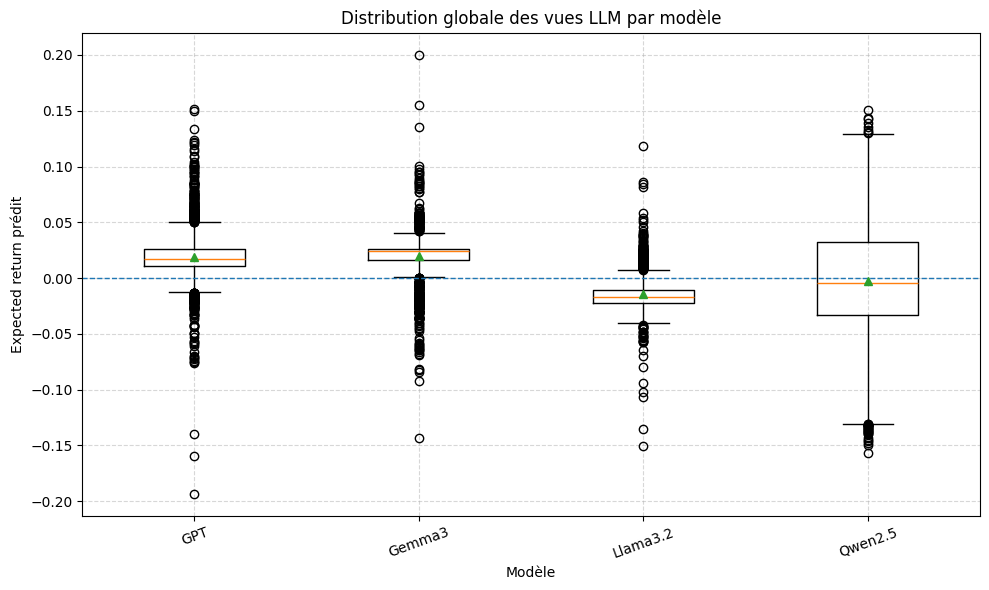

In [24]:
plt.figure(figsize=(10, 6))

data = [
    views.loc[views["model"] == model, "expected_return"].dropna().values
    for model in sorted(views["model"].unique())
]
labels = sorted(views["model"].unique())

plt.boxplot(data, tick_labels=labels, showmeans=True)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Distribution globale des vues LLM par modèle")
plt.ylabel("Expected return prédit")
plt.xlabel("Modèle")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 3. Boxplots des vues dans le temps

Cette analyse se rapproche de l’analyse de style de l’article.  
À chaque date de rééquilibrage, le boxplot représente la distribution des vues produites par un modèle pour l’ensemble des titres.  

Lecture :
- une boîte située plus haut indique un modèle plus optimiste à cette date;
- une boîte plus large indique une dispersion plus forte des vues;
- des outliers indiquent des titres pour lesquels le LLM a produit des vues particulièrement fortes;
- une évolution instable des boîtes suggère un style moins stable dans le temps.


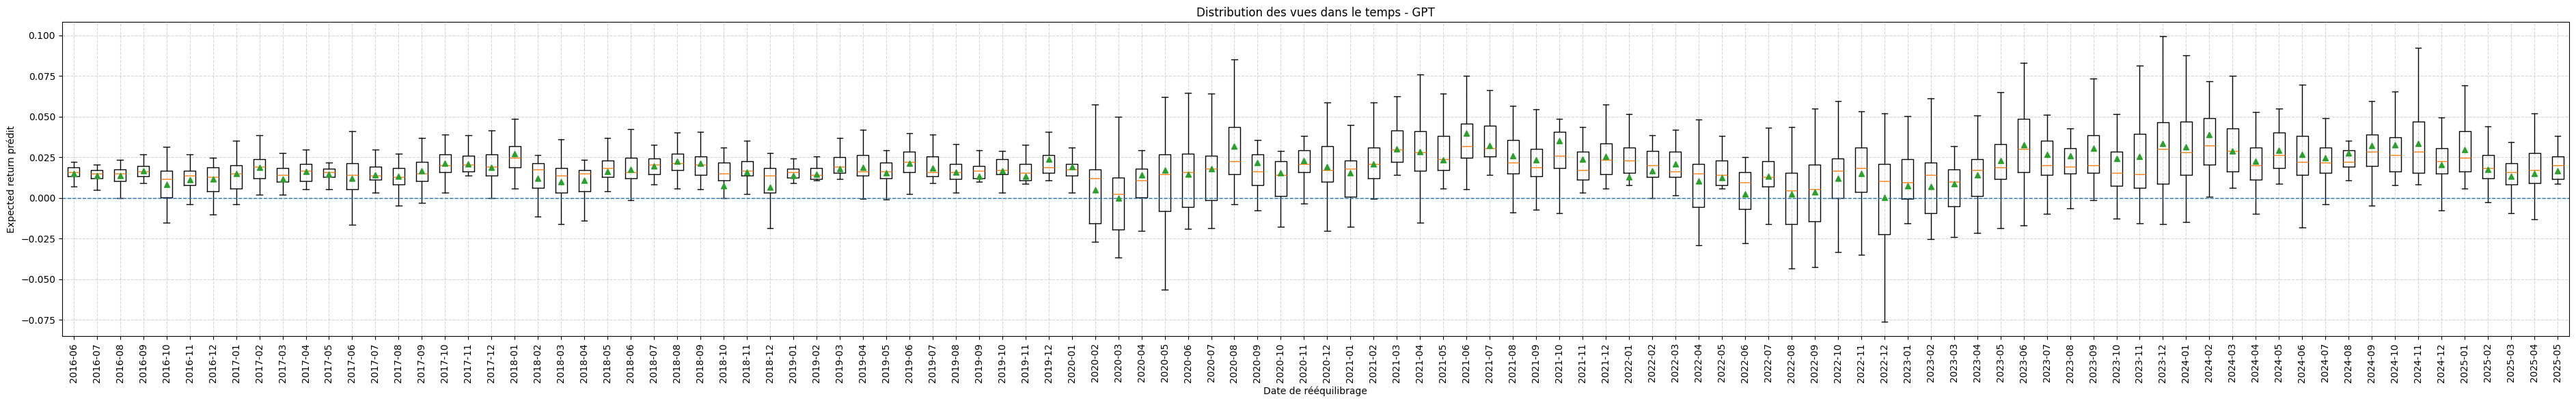

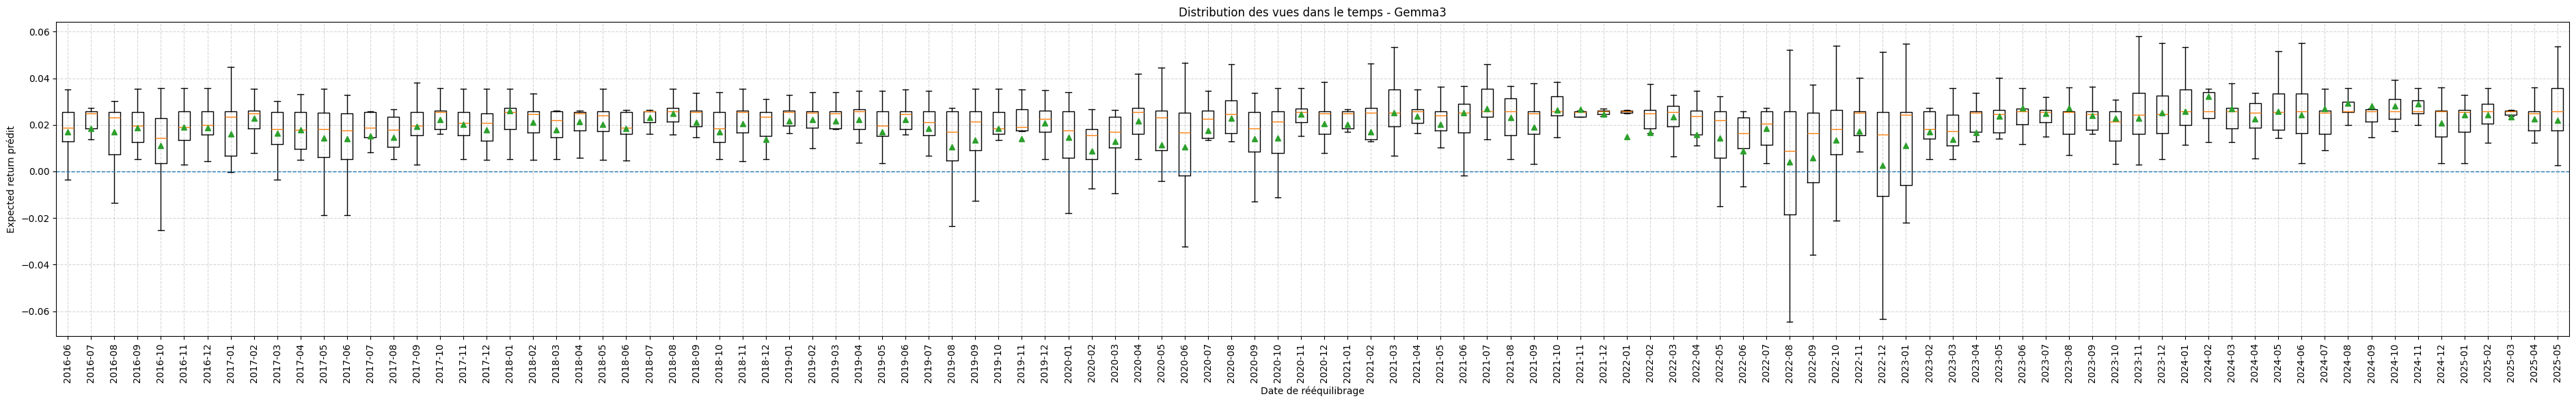

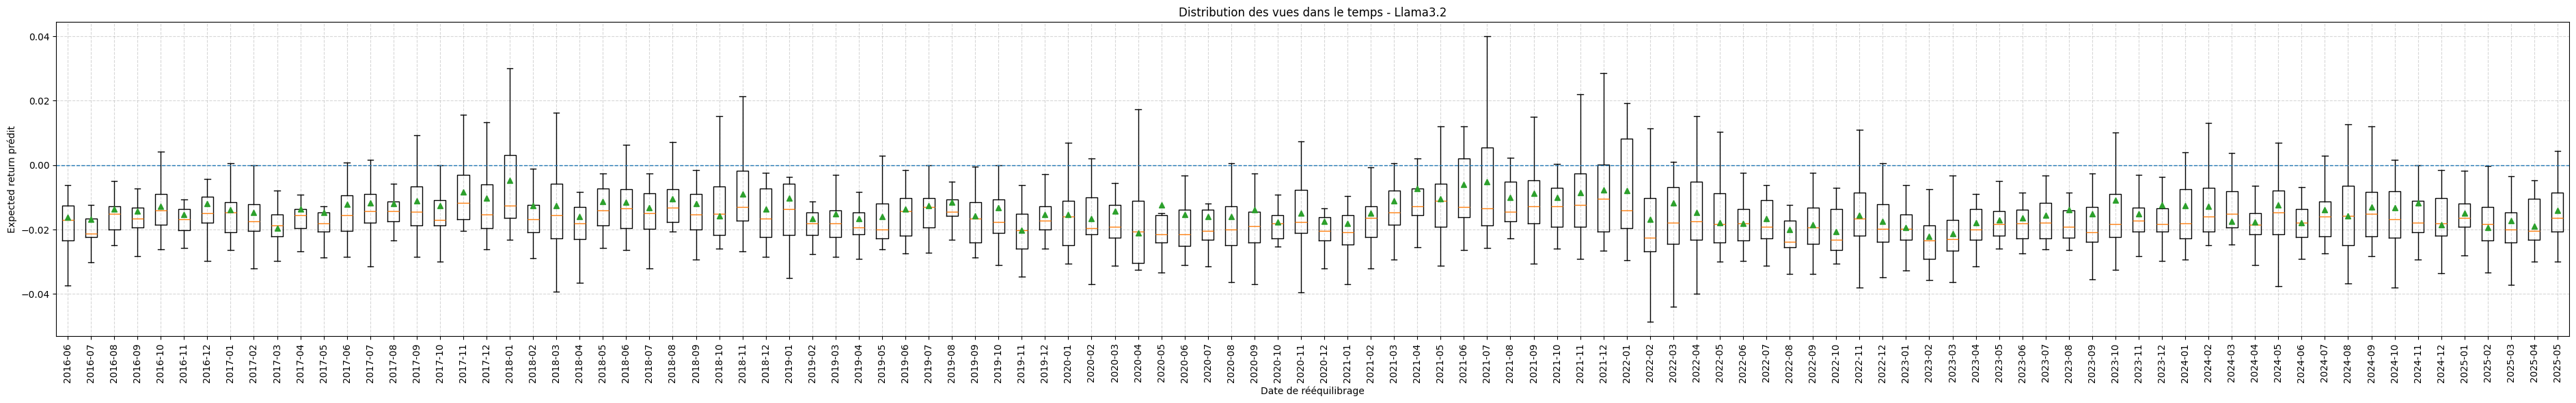

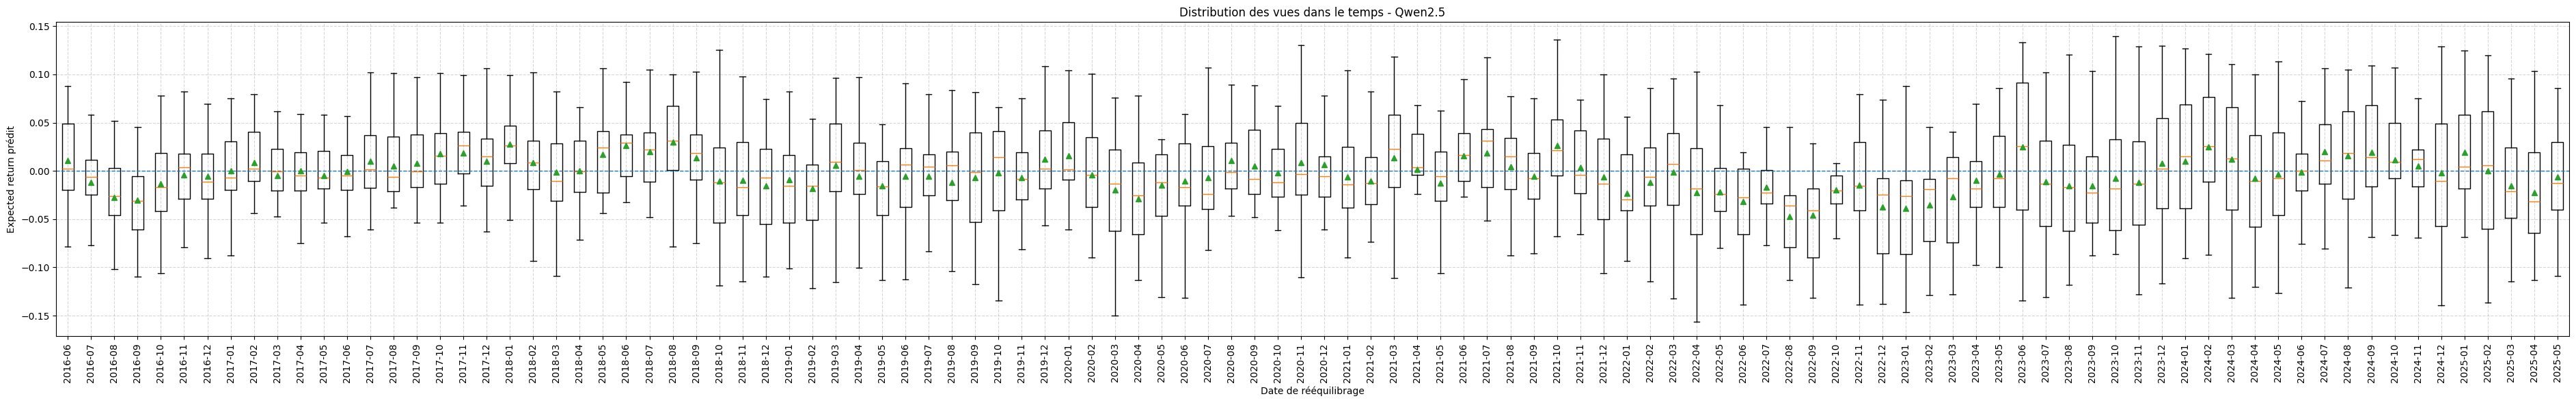

In [25]:
def plot_time_boxplots_for_model(views_df: pd.DataFrame, model: str, max_dates=None):
    d = views_df[views_df["model"] == model].copy()
    d = d.sort_values("rebalance_date")

    dates = sorted(d["rebalance_date"].dropna().unique())
    if max_dates is not None:
        dates = dates[-max_dates:]

    data = [
        d.loc[d["rebalance_date"] == dt, "expected_return"].dropna().values
        for dt in dates
    ]

    labels = [pd.to_datetime(dt).strftime("%Y-%m") for dt in dates]

    plt.figure(figsize=(max(12, len(labels) * 0.35), 6))
    plt.boxplot(data, tick_labels=labels, showmeans=True, showfliers=False)
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Distribution des vues dans le temps - {model}")
    plt.ylabel("Expected return prédit")
    plt.xlabel("Date de rééquilibrage")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


for model in sorted(views["model"].unique()):
    plot_time_boxplots_for_model(views, model)


## 4. Évolution de la vue moyenne par modèle

Cette figure résume l’évolution du niveau moyen des vues.  
Elle permet de voir si un modèle devient plus optimiste ou pessimiste pendant certaines périodes.


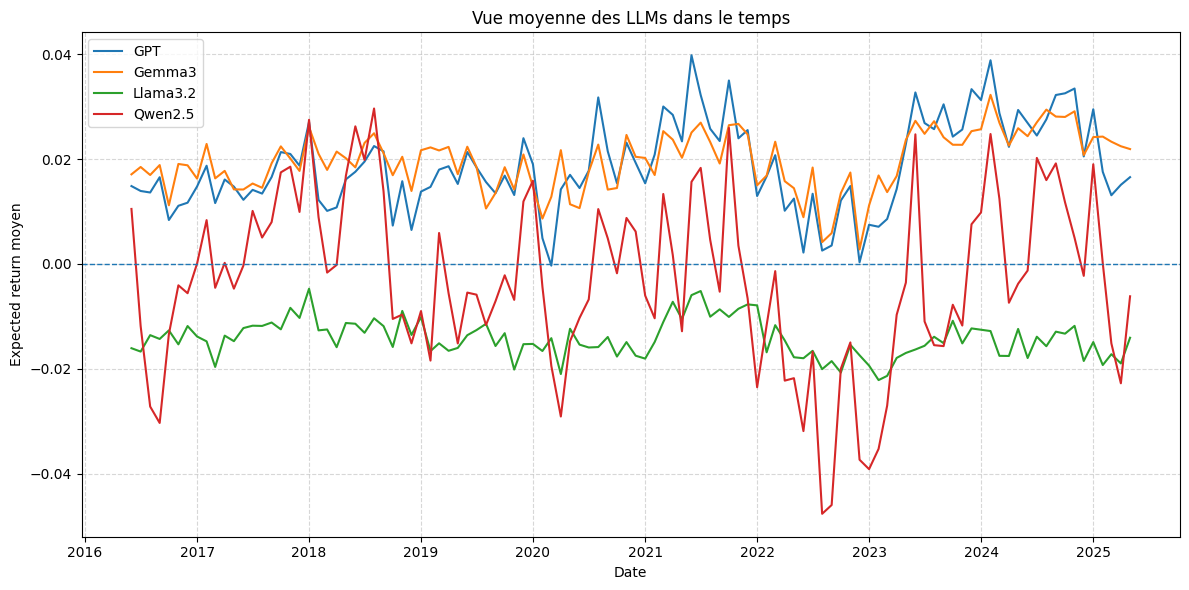

model,GPT,Gemma3,Llama3.2,Qwen2.5
rebalance_date,,,,
2025-01-01,0.029510,0.024191,-0.014904,0.019010
2025-02-01,0.017564,0.024291,-0.019287,0.000135
2025-03-01,0.013101,0.023317,-0.017218,-0.015147
2025-04-01,0.015091,0.022452,-0.018981,-0.022772
2025-05-01,0.016552,0.021910,-0.014080,-0.006173


In [26]:
mean_views_ts = (
    views
    .groupby(["rebalance_date", "model"])["expected_return"]
    .mean()
    .unstack("model")
    .sort_index()
)

plt.figure(figsize=(12, 6))

for model in mean_views_ts.columns:
    plt.plot(mean_views_ts.index, mean_views_ts[model], label=model)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Vue moyenne des LLMs dans le temps")
plt.ylabel("Expected return moyen")
plt.xlabel("Date")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

display(mean_views_ts.tail())


## 5. Évolution de la dispersion des vues

La dispersion est mesurée par l’écart-type transversal des vues à chaque date.  
Une dispersion plus élevée signifie que le modèle différencie davantage les titres entre eux.


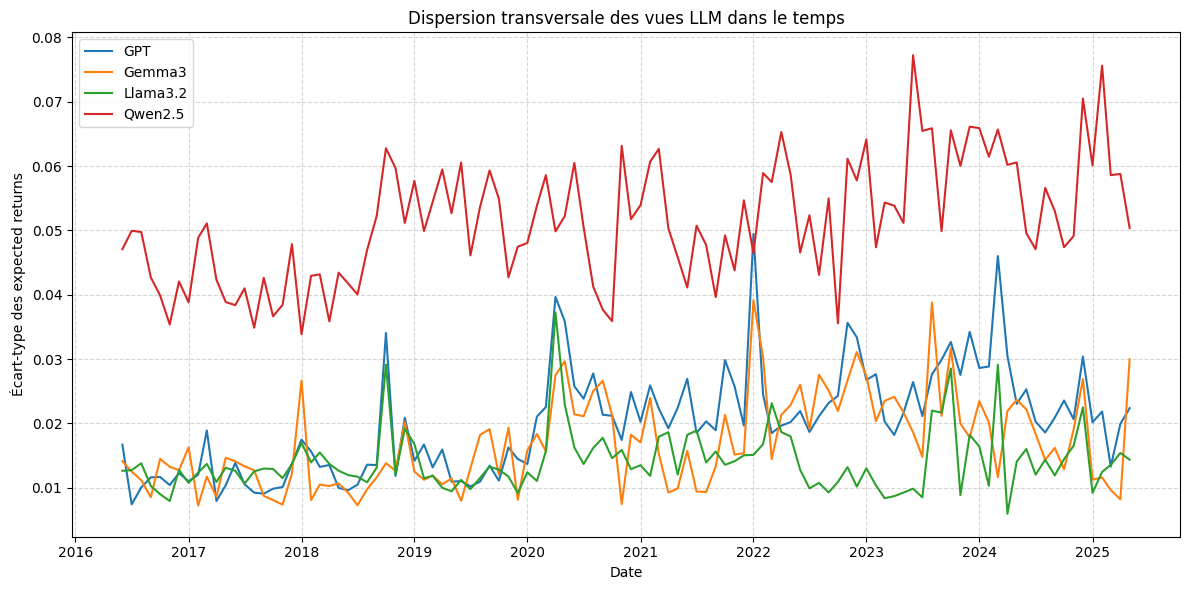

model,GPT,Gemma3,Llama3.2,Qwen2.5
rebalance_date,,,,
2025-01-01,0.020186,0.011275,0.009225,0.060112
2025-02-01,0.021852,0.011605,0.012462,0.075618
2025-03-01,0.013310,0.009650,0.013570,0.058598
2025-04-01,0.019948,0.008202,0.015422,0.058782
2025-05-01,0.022376,0.029976,0.014382,0.050375


In [27]:
std_views_ts = (
    views
    .groupby(["rebalance_date", "model"])["expected_return"]
    .std()
    .unstack("model")
    .sort_index()
)

plt.figure(figsize=(12, 6))

for model in std_views_ts.columns:
    plt.plot(std_views_ts.index, std_views_ts[model], label=model)

plt.title("Dispersion transversale des vues LLM dans le temps")
plt.ylabel("Écart-type des expected returns")
plt.xlabel("Date")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

display(std_views_ts.tail())


## 6. Proportion de vues positives

Cette analyse mesure le sentiment global de chaque LLM.  
Un ratio près de 1 indique que presque toutes les vues sont positives.  
Un ratio près de 0 indique un modèle très pessimiste.  
Un ratio près de 0,5 indique un modèle plus neutre ou plus sélectif.


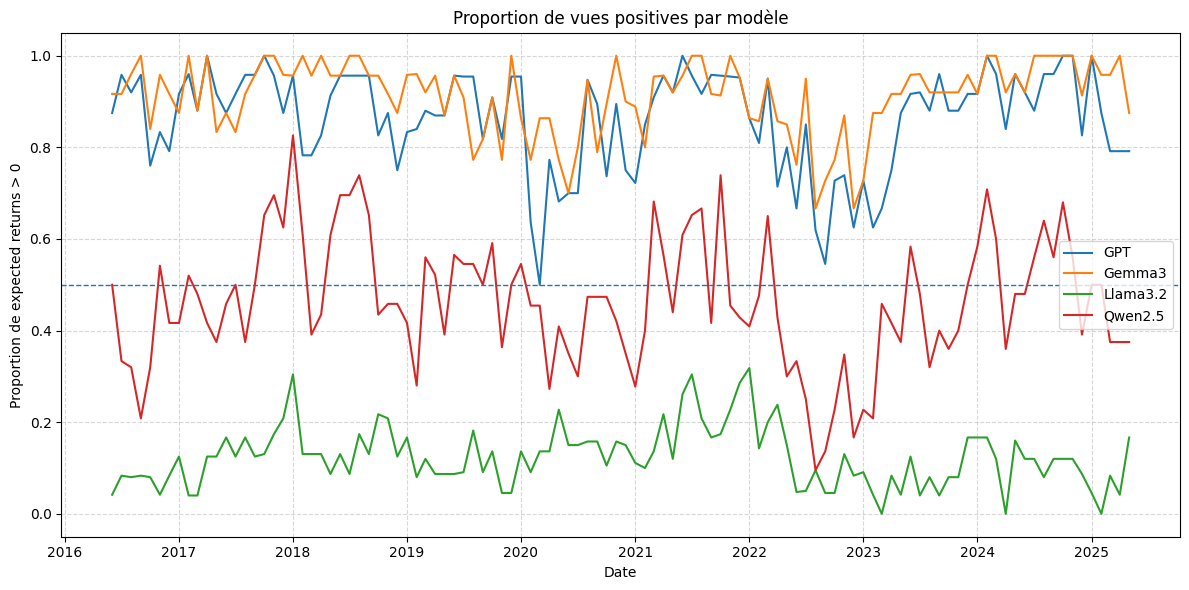

model,GPT,Gemma3,Llama3.2,Qwen2.5
rebalance_date,,,,
2025-01-01,1.000000,1.000000,0.045455,0.500000
2025-02-01,0.875000,0.958333,0.000000,0.500000
2025-03-01,0.791667,0.958333,0.083333,0.375000
2025-04-01,0.791667,1.000000,0.041667,0.375000
2025-05-01,0.791667,0.875000,0.166667,0.375000


In [28]:
positive_ratio_ts = (
    views
    .groupby(["rebalance_date", "model"])["positive_view"]
    .mean()
    .unstack("model")
    .sort_index()
)

plt.figure(figsize=(12, 6))

for model in positive_ratio_ts.columns:
    plt.plot(positive_ratio_ts.index, positive_ratio_ts[model], label=model)

plt.axhline(0.5, linestyle="--", linewidth=1)
plt.ylim(-0.05, 1.05)
plt.title("Proportion de vues positives par modèle")
plt.ylabel("Proportion de expected returns > 0")
plt.xlabel("Date")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

display(positive_ratio_ts.tail())


## 7. Classification simple du style d’investissement

Cette section crée une lecture synthétique du style de chaque modèle selon deux dimensions :

- **niveau moyen des vues** : optimiste, neutre ou pessimiste;
- **dispersion des vues** : prudent/stable ou agressif/différencié.

Les seuils sont volontairement simples et peuvent être ajustés selon ton interprétation.


In [29]:
style = summary_by_model.copy()

# Seuils simples, modifiables au besoin
mean_threshold = 0.00
high_dispersion_threshold = style["std"].median()

def classify_sentiment(x):
    if x > mean_threshold:
        return "Optimiste"
    elif x < mean_threshold:
        return "Pessimiste"
    else:
        return "Neutre"

def classify_dispersion(x):
    if x >= high_dispersion_threshold:
        return "Vues dispersées / style plus agressif"
    else:
        return "Vues concentrées / style plus prudent"

style["sentiment_style"] = style["mean"].apply(classify_sentiment)
style["dispersion_style"] = style["std"].apply(classify_dispersion)

style = style[
    [
        "model",
        "n_views",
        "mean",
        "median",
        "std",
        "positive_view_ratio",
        "sentiment_style",
        "dispersion_style",
    ]
]

display(style)


,model,n_views,mean,median,std,positive_view_ratio,sentiment_style,dispersion_style
0,GPT,2487,0.018787,0.017507,0.022748,0.864495,Optimiste,Vues dispersées / style plus agressif
1,Gemma3,2487,0.019784,0.024570,0.018800,0.913953,Optimiste,Vues concentrées / style plus prudent
2,Llama3.2,2487,-0.014197,-0.016755,0.014955,0.122236,Pessimiste,Vues concentrées / style plus prudent
3,Qwen2.5,2487,-0.002991,-0.004206,0.053687,0.464817,Pessimiste,Vues dispersées / style plus agressif


## 8. Tableau mensuel exportable

Ce tableau peut être utilisé directement dans le texte de l’essai ou exporté en CSV.  
Il résume, pour chaque modèle et chaque date, la moyenne, la dispersion et la proportion de vues positives.


In [30]:
monthly_style = (
    views
    .groupby(["rebalance_date", "model"])
    .agg(
        n_views=("expected_return", "count"),
        mean_view=("expected_return", "mean"),
        median_view=("expected_return", "median"),
        std_view=("expected_return", "std"),
        min_view=("expected_return", "min"),
        max_view=("expected_return", "max"),
        positive_view_ratio=("positive_view", "mean"),
    )
    .reset_index()
    .sort_values(["rebalance_date", "model"])
)

display(monthly_style.head(20))

out_path = "llm_investment_style_monthly_summary.csv"
monthly_style.to_csv(out_path, index=False)
print(f"Tableau exporté: {out_path}")


,rebalance_date,model,n_views,mean_view,median_view,std_view,min_view,max_view,positive_view_ratio
0,2016-06-01,GPT,24,0.014851,0.016002,0.016712,-0.026167,0.062274,0.875000
1,2016-06-01,Gemma3,24,0.017092,0.018810,0.014153,-0.030000,0.044760,0.916667
2,2016-06-01,Llama3.2,24,-0.016075,-0.016920,0.012650,-0.037371,0.034376,0.041667
3,2016-06-01,Qwen2.5,24,0.010490,0.002308,0.047085,-0.078247,0.087790,0.500000
4,2016-07-01,GPT,24,0.013916,0.014836,0.007437,-0.009827,0.032220,0.958333
5,2016-07-01,Gemma3,24,0.018493,0.024995,0.012516,-0.017873,0.027253,0.916667
6,2016-07-01,Llama3.2,24,-0.016719,-0.021303,0.012747,-0.030138,0.024408,0.083333
7,2016-07-01,Qwen2.5,24,-0.011877,-0.005993,0.049946,-0.112375,0.092058,0.333333
8,2016-08-01,GPT,25,0.013625,0.014883,0.010060,-0.022270,0.035867,0.920000
9,2016-08-01,Gemma3,25,0.016968,0.023077,0.011194,-0.013537,0.030330,0.960000


Tableau exporté: llm_investment_style_monthly_summary.csv


## 9. Interprétation à rédiger dans l’essai

À compléter après avoir exécuté le notebook avec tes fichiers :

- Un modèle dont la moyenne des vues est plus élevée peut être interprété comme plus optimiste.
- Un modèle dont la dispersion des vues est plus élevée accorde des prévisions plus différenciées entre les titres.
- Un modèle avec une forte proportion de vues positives est plus aligné avec un régime de marché haussier.
- Un modèle dont les vues changent fortement d’un mois à l’autre peut générer davantage de turnover dans le portefeuille Black-Litterman.
- Une bonne performance peut donc provenir soit d’une meilleure capacité prédictive, soit d’un style de vues mieux aligné avec le régime de marché observé.



## 10. Alignement des vues avec le régime de marché

Cette section compare le sentiment des vues LLM avec le régime de marché observé. L’idée est simple : un modèle qui produit beaucoup de vues positives devrait être avantagé dans un régime haussier, mais désavantagé dans un régime baissier.  

Le régime est défini à partir du rendement mensuel du marché de référence. Par défaut, le notebook tente d’utiliser un fichier local si disponible, sinon il télécharge `SPY` avec `yfinance`.


Aucun fichier local trouvé. Téléchargement de SPY avec yfinance...


,model,n_months,avg_positive_ratio,avg_market_return_when_model_bullish,avg_market_return_when_model_bearish,alignment_rate_1m,corr_positive_ratio_market_return
0,GPT,107,0.861990,0.012110,NaN,0.700935,0.403365
1,Gemma3,107,0.911805,0.012110,NaN,0.700935,0.287752
2,Llama3.2,107,0.124091,NaN,0.012110,0.299065,0.087430
3,Qwen2.5,107,0.462857,0.026678,0.002697,0.598131,0.219860


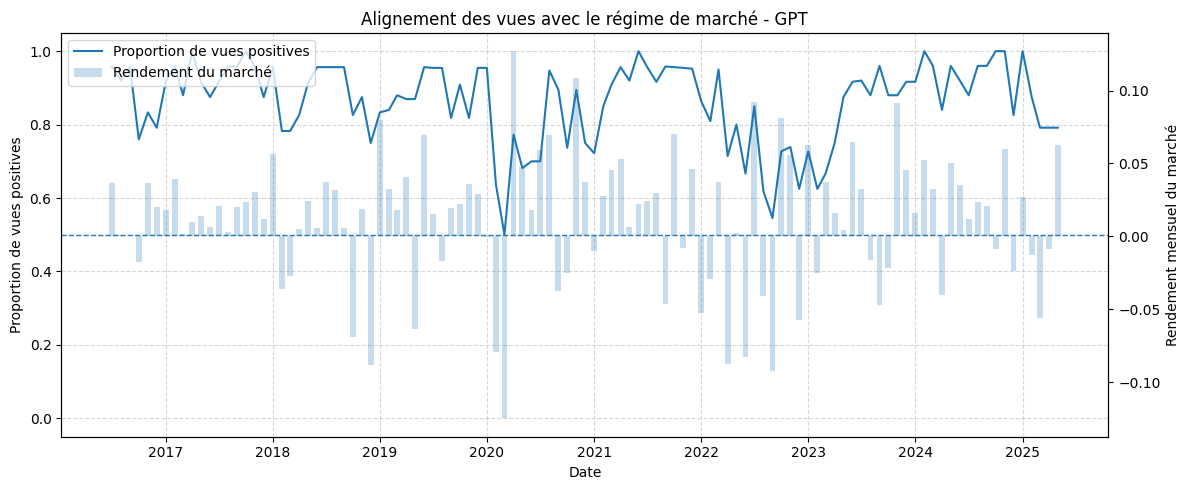

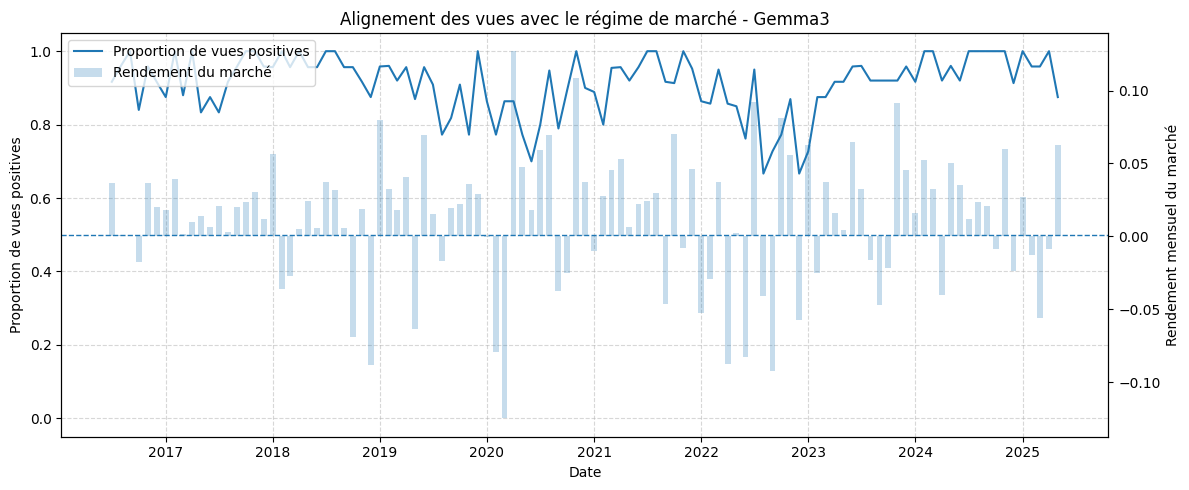

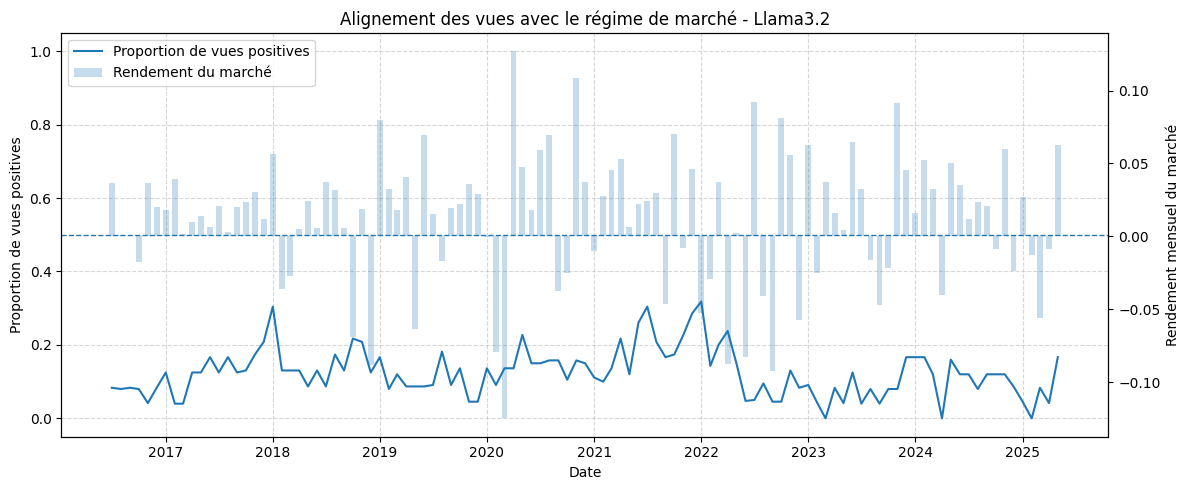

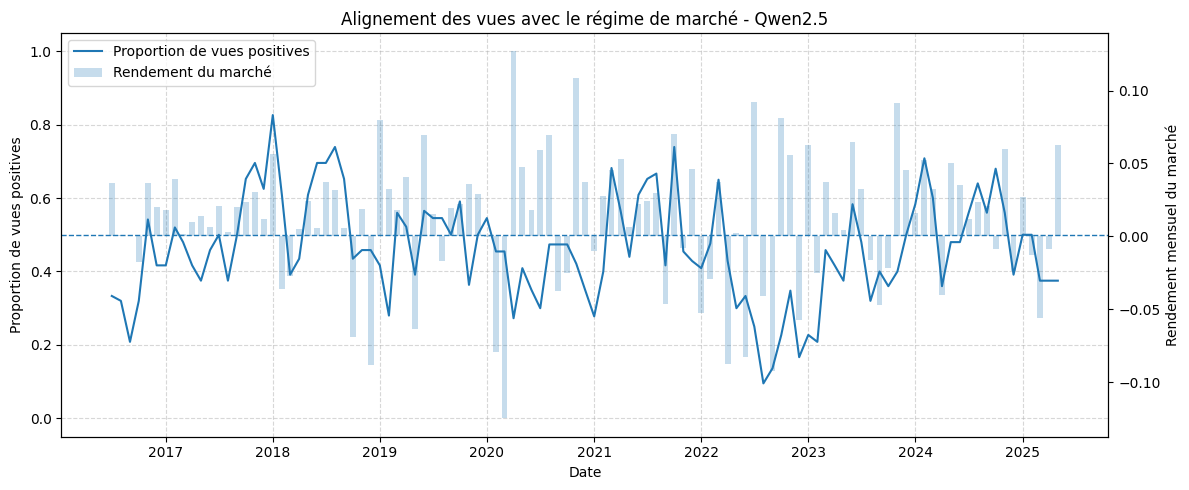

In [31]:
# ============================
# Régime de marché
# ============================

MARKET_TICKER = "SPY"

# Le notebook essaie d'abord de trouver un fichier local.
# Tu peux ajouter ici un chemin spécifique si ton rendement du S&P 500/SPY est ailleurs.
MARKET_RETURN_CANDIDATES = [
    "responses_portfolios/sp500_proxy.csv",
    "responses_portfolios/SP500_proxy.csv",
    "responses_portfolios/spy_proxy.csv",
    "responses_portfolios/SPY_proxy.csv",
    "results/sp500_proxy.csv",
    "results/SP500_proxy.csv",
    "results/spy_proxy.csv",
    "results/SPY_proxy.csv",
    "results/baseline_returns.csv",
    "results/baselines_returns.csv",
    "baseline_returns.csv",
    "baselines_returns.csv",
    "portfolio_returns.csv",
]


def _standardize_return_series_from_df(df: pd.DataFrame, name: str = "Market", return_col=None) -> pd.Series:
    """
    Retourne une série de rendements mensuels indexée au début du mois.

    La fonction est volontairement robuste aux noms de colonnes fréquents:
    - date_key, Date, date, month, ym, year-month
    - Portfolio_Return, SPY, SP500, sp500_return, market_return, etc.
    """
    df = df.copy()

    # 1) Détection de la date
    date_candidates = [
        "date_key", "Date", "date", "month", "Month", "ym", "year_month", "year-month", "YearMonth"
    ]
    date_col = next((c for c in date_candidates if c in df.columns), None)

    if date_col is not None:
        if date_col in {"ym", "year_month", "year-month", "YearMonth"}:
            dt = pd.to_datetime(df[date_col].astype(str).str[:7] + "-01", errors="coerce")
        else:
            dt = pd.to_datetime(df[date_col], errors="coerce")
    else:
        # Si la date est dans l'index après un read_csv(index_col=0) éventuel
        if isinstance(df.index, pd.DatetimeIndex):
            dt = pd.Series(df.index, index=df.index)
        else:
            raise ValueError(f"{name}: aucune colonne de date trouvée. Colonnes: {list(df.columns)}")

    # 2) Détection de la colonne de rendement
    if return_col is None:
        candidates = [
            "SPY", "SP500", "S&P500", "S&P 500",
            "sp500", "sp500_return", "spy_return",
            "market_return", "Market_Return",
            "Portfolio_Return", "portfolio_return",
            "return", "returns", "ret", "monthly_return",
            "benchmark_return", "Benchmark_Return",
        ]
        return_col = next((c for c in candidates if c in df.columns), None)

        # Cas fréquent: fichier avec plusieurs colonnes de portefeuilles.
        # On privilégie une colonne qui ressemble au S&P 500 ou SPY.
        if return_col is None:
            lower_map = {c.lower(): c for c in df.columns}
            for key in lower_map:
                if "spy" in key or "sp500" in key or "s&p" in key:
                    return_col = lower_map[key]
                    break

        # Sinon, si une seule colonne numérique non-date existe, on l'utilise.
        if return_col is None:
            excluded = set(date_candidates)
            numeric_cols = [
                c for c in df.columns
                if c not in excluded and pd.api.types.is_numeric_dtype(df[c])
            ]
            if len(numeric_cols) == 1:
                return_col = numeric_cols[0]
            else:
                raise ValueError(
                    f"{name}: impossible d'identifier la colonne de rendement. "
                    f"Colonnes numériques candidates: {numeric_cols}. Colonnes complètes: {list(df.columns)}"
                )

    s = pd.Series(pd.to_numeric(df[return_col], errors="coerce").values, index=pd.to_datetime(dt, errors="coerce"))
    s = s.dropna()
    s.index = pd.DatetimeIndex(s.index).to_period("M").to_timestamp()
    s = s[~s.index.duplicated(keep="last")].sort_index()
    s.name = name
    return s


def _try_load_market_from_local_files() -> pd.Series | None:
    """
    Essaie plusieurs fichiers CSV locaux.
    Retourne None si aucun fichier utilisable n'est trouvé.
    """
    for path in MARKET_RETURN_CANDIDATES:
        path = Path(path)
        if not path.exists():
            continue

        try:
            df = pd.read_csv(path)
            s = _standardize_return_series_from_df(df, name="Market")
            if len(s) > 0:
                print(f"Rendement de marché chargé depuis: {path}")
                return s
        except Exception as e:
            print(f"Fichier de marché ignoré: {path} | Erreur: {e}")

    return None


def _try_load_market_from_yfinance_returns_folder() -> pd.Series | None:
    """
    Essaie de reconstruire un proxy marché à partir des fichiers yfinance/returns_*.csv si SPY y est présent.
    Utile dans ton projet parce que les rendements mensuels sont souvent déjà sauvegardés localement.
    """
    returns_files = sorted(Path("yfinance").glob("returns_*.csv"))
    pieces = []

    for fp in returns_files:
        try:
            df = pd.read_csv(fp)

            # Format 1: date_key + SPY comme colonne
            if "SPY" in df.columns:
                s = _standardize_return_series_from_df(df, name="Market", return_col="SPY")
                pieces.append(s)
                continue

            # Format 2: long format avec ticker et return
            ticker_col = next((c for c in ["ticker", "Ticker", "symbol", "Symbol"] if c in df.columns), None)
            if ticker_col is not None and df[ticker_col].astype(str).str.upper().eq("SPY").any():
                ret_col = next((c for c in ["return", "returns", "ret", "stock_ret", "Portfolio_Return"] if c in df.columns), None)
                if ret_col is not None:
                    spy_df = df[df[ticker_col].astype(str).str.upper().eq("SPY")].copy()
                    s = _standardize_return_series_from_df(spy_df, name="Market", return_col=ret_col)
                    pieces.append(s)
        except Exception as e:
            print(f"Fichier returns ignoré pour le régime: {fp} | Erreur: {e}")

    if pieces:
        out = pd.concat(pieces).sort_index()
        out = out[~out.index.duplicated(keep="last")]
        print("Rendement de marché reconstruit depuis yfinance/returns_*.csv")
        return out

    return None


def load_market_returns(start=START, end=END) -> pd.Series:
    """
    Charge les rendements mensuels du marché.
    Ordre:
    1) fichiers CSV locaux explicites;
    2) fichiers yfinance/returns_*.csv si SPY est présent;
    3) téléchargement yfinance;
    4) message d'erreur clair.
    """
    s = _try_load_market_from_local_files()
    if s is not None:
        return s

    s = _try_load_market_from_yfinance_returns_folder()
    if s is not None:
        return s

    try:
        import yfinance as yf
    except ImportError as exc:
        raise ImportError(
            "Aucun fichier local de rendement de marché n'a été trouvé et yfinance n'est pas installé. "
            "Solution recommandée: ajoute un CSV avec une colonne de date et une colonne de rendement SPY/S&P500, "
            "par exemple results/sp500_proxy.csv."
        ) from exc

    print(f"Aucun fichier local trouvé. Téléchargement de {MARKET_TICKER} avec yfinance...")
    px = yf.download(MARKET_TICKER, start=start, end=end, progress=False, auto_adjust=False)

    if px.empty:
        raise ValueError(
            f"Aucune donnée téléchargée pour {MARKET_TICKER}. "
            "Ajoute plutôt un fichier CSV local de rendements mensuels du marché."
        )

    close = px["Adj Close"] if "Adj Close" in px.columns else px["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]

    monthly_close = close.dropna().resample("ME").last()
    monthly_ret = monthly_close.pct_change().dropna()
    monthly_ret.index = monthly_ret.index.to_period("M").to_timestamp()
    monthly_ret.name = "Market"
    return monthly_ret


market_returns = load_market_returns()
market_returns = market_returns[
    (market_returns.index >= START_DT.to_period("M").to_timestamp()) &
    (market_returns.index <= END_DT.to_period("M").to_timestamp())
].copy()

if market_returns.empty:
    raise ValueError(
        "Les rendements de marché ont été chargés, mais aucune observation ne tombe dans la période START-END."
    )

# Régimes simples : mensuel et tendance 3 mois.
market_regime = pd.DataFrame({"market_return": market_returns})
market_regime.index = pd.DatetimeIndex(market_regime.index).to_period("M").to_timestamp()
market_regime.index.name = "month"

market_regime["regime_1m"] = np.where(market_regime["market_return"] >= 0, "Haussier", "Baissier")
market_regime["market_return_3m"] = (1 + market_regime["market_return"]).rolling(3).apply(np.prod, raw=True) - 1
market_regime["regime_3m"] = np.where(market_regime["market_return_3m"] >= 0, "Haussier", "Baissier")

# Alignement avec les vues mensuelles.
view_regime = monthly_style.copy()
view_regime["month"] = pd.to_datetime(view_regime["rebalance_date"]).dt.to_period("M").dt.to_timestamp()

market_regime_for_merge = market_regime.reset_index()
view_regime = view_regime.merge(market_regime_for_merge, on="month", how="left")

# Alignement directionnel :
# - sentiment LLM haussier si plus de 50% des vues sont positives;
# - marché haussier si le rendement mensuel du marché est positif.
view_regime["sentiment_direction"] = np.where(view_regime["positive_view_ratio"] >= 0.5, 1, -1)
view_regime["market_direction"] = np.where(view_regime["market_return"] >= 0, 1, -1)
view_regime["aligned_1m"] = view_regime["sentiment_direction"] == view_regime["market_direction"]

def _safe_mean_market_return_when(mask):
    vals = view_regime.loc[mask, "market_return"].dropna()
    return vals.mean() if len(vals) > 0 else np.nan

alignment_rows = []
for model, d in view_regime.dropna(subset=["market_return"]).groupby("model"):
    bullish = d["positive_view_ratio"] >= 0.5
    bearish = d["positive_view_ratio"] < 0.5

    corr = np.nan
    if d["positive_view_ratio"].nunique(dropna=True) > 1 and d["market_return"].nunique(dropna=True) > 1:
        corr = d["positive_view_ratio"].corr(d["market_return"])

    alignment_rows.append({
        "model": model,
        "n_months": len(d),
        "avg_positive_ratio": d["positive_view_ratio"].mean(),
        "avg_market_return_when_model_bullish": d.loc[bullish, "market_return"].mean(),
        "avg_market_return_when_model_bearish": d.loc[bearish, "market_return"].mean(),
        "alignment_rate_1m": d["aligned_1m"].mean(),
        "corr_positive_ratio_market_return": corr,
    })

alignment_summary = pd.DataFrame(alignment_rows)
display(alignment_summary)

# Export
OUTPUT_DIR = globals().get("OUTPUT_DIR", Path("style_analysis_outputs"))
OUTPUT_DIR.mkdir(exist_ok=True)
alignment_summary.to_csv(OUTPUT_DIR / "market_regime_alignment_summary.csv", index=False)
view_regime.to_csv(OUTPUT_DIR / "market_regime_alignment_monthly.csv", index=False)

def plot_regime_alignment_for_model(model: str):
    d = view_regime[view_regime["model"] == model].dropna(subset=["market_return"]).sort_values("month")
    if d.empty:
        print(f"Aucune donnée disponible pour {model}.")
        return

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(d["month"], d["positive_view_ratio"], label="Proportion de vues positives")
    ax1.axhline(0.5, linestyle="--", linewidth=1)
    ax1.set_ylabel("Proportion de vues positives")
    ax1.set_ylim(-0.05, 1.05)
    ax1.grid(True, linestyle="--", alpha=0.5)

    ax2 = ax1.twinx()
    ax2.bar(d["month"], d["market_return"], width=20, alpha=0.25, label="Rendement du marché")
    ax2.set_ylabel("Rendement mensuel du marché")

    ax1.set_title(f"Alignement des vues avec le régime de marché - {model}")
    ax1.set_xlabel("Date")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    fig.tight_layout()
    plt.show()

for model in sorted(view_regime["model"].dropna().unique()):
    plot_regime_alignment_for_model(model)


## 11. Instabilité des vues dans le temps

Cette section mesure si les vues changent beaucoup d’un mois à l’autre. Une forte instabilité peut se traduire par des poids plus variables, un turnover plus élevé et potentiellement des coûts de transaction plus importants.

Les mesures utilisées sont :
- la variation absolue moyenne des vues pour un même titre entre deux mois;
- le ratio de changements de signe des vues;
- la corrélation moyenne entre les vues d’un mois et celles du mois précédent.


,model,n_months,avg_mean_abs_view_change,avg_sign_change_ratio,avg_corr_with_previous
0,GPT,108,0.009298,0.050172,0.774475
1,Gemma3,108,0.010178,0.052110,0.498783
2,Llama3.2,108,0.007638,0.044143,0.678458
3,Qwen2.5,108,0.032041,0.135228,0.631289


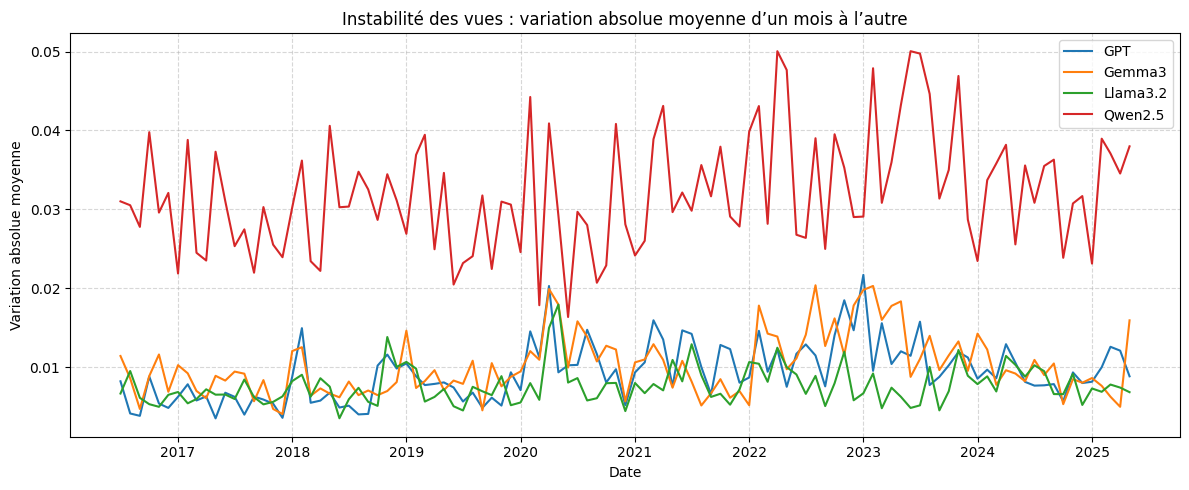

model,GPT,Gemma3,Llama3.2,Qwen2.5
rebalance_date,,,,
2025-01-01,0.008136,0.008604,0.007281,0.023117
2025-02-01,0.009979,0.007613,0.006860,0.038957
2025-03-01,0.012566,0.006239,0.007779,0.037084
2025-04-01,0.012079,0.004958,0.007394,0.034539
2025-05-01,0.008825,0.015921,0.006814,0.037988


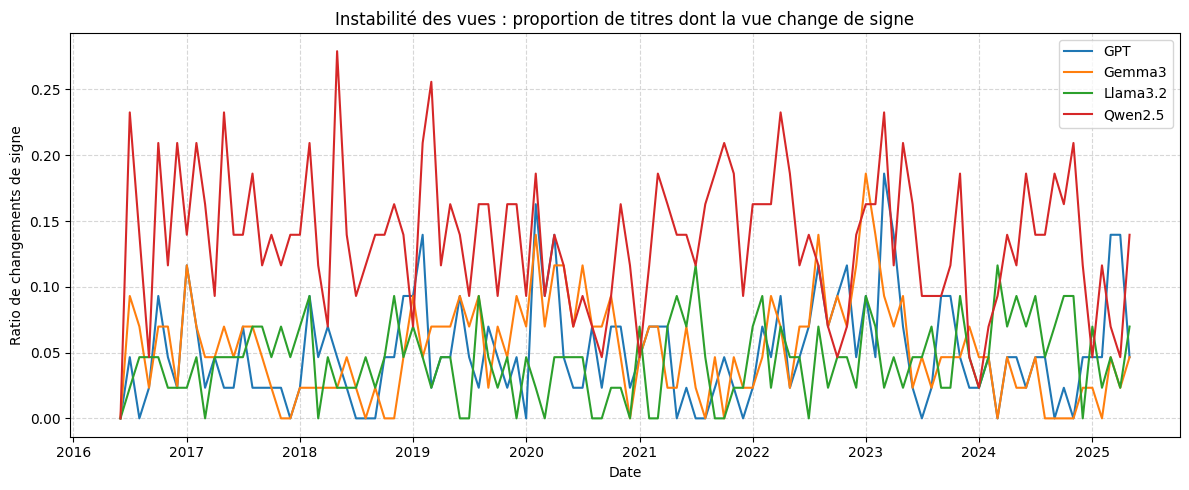

model,GPT,Gemma3,Llama3.2,Qwen2.5
rebalance_date,,,,
2025-01-01,0.046512,0.023256,0.069767,0.046512
2025-02-01,0.046512,0.000000,0.023256,0.116279
2025-03-01,0.139535,0.046512,0.046512,0.069767
2025-04-01,0.139535,0.023256,0.023256,0.046512
2025-05-01,0.046512,0.046512,0.069767,0.139535


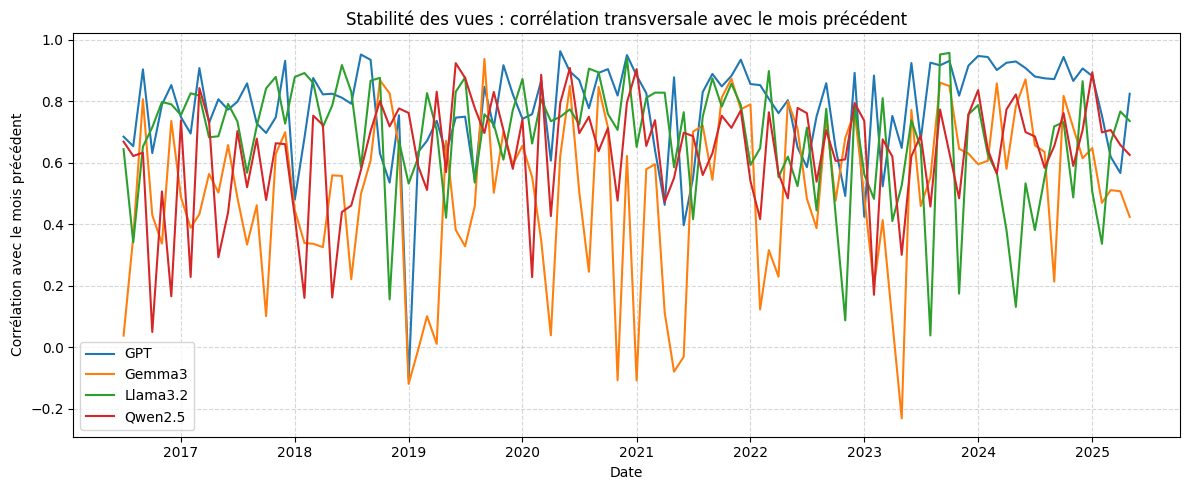

model,GPT,Gemma3,Llama3.2,Qwen2.5
rebalance_date,,,,
2025-01-01,0.882255,0.647622,0.505468,0.894463
2025-02-01,0.753519,0.469718,0.336218,0.698730
2025-03-01,0.619445,0.510944,0.665901,0.706497
2025-04-01,0.566514,0.507169,0.766782,0.657927
2025-05-01,0.824464,0.423885,0.735829,0.625450


In [32]:

# ============================
# Instabilité des vues
# ============================

def compute_view_instability(views_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    detailed_rows = []

    for model, d in views_df.sort_values(["model", "ticker", "rebalance_date"]).groupby("model"):
        wide = d.pivot_table(
            index="rebalance_date",
            columns="ticker",
            values="expected_return",
            aggfunc="mean"
        ).sort_index()

        diff = wide.diff()
        abs_change_ts = diff.abs().mean(axis=1, skipna=True)

        sign = np.sign(wide)
        sign_change = (sign != sign.shift(1)) & sign.notna() & sign.shift(1).notna()
        sign_change_ratio_ts = sign_change.sum(axis=1) / sign_change.count(axis=1).replace(0, np.nan)

        corr_with_previous = []
        for i in range(1, len(wide)):
            prev = wide.iloc[i - 1]
            curr = wide.iloc[i]
            valid = prev.notna() & curr.notna()
            if valid.sum() >= 2:
                corr_with_previous.append((wide.index[i], prev[valid].corr(curr[valid])))
            else:
                corr_with_previous.append((wide.index[i], np.nan))
        corr_ts = pd.Series(dict(corr_with_previous), name="corr_with_previous")

        tmp = pd.DataFrame({
            "model": model,
            "rebalance_date": wide.index,
            "mean_abs_view_change": abs_change_ts.reindex(wide.index).values,
            "sign_change_ratio": sign_change_ratio_ts.reindex(wide.index).values,
            "corr_with_previous": corr_ts.reindex(wide.index).values,
        })
        detailed_rows.append(tmp)

        rows.append({
            "model": model,
            "n_months": len(wide),
            "avg_mean_abs_view_change": abs_change_ts.mean(),
            "avg_sign_change_ratio": sign_change_ratio_ts.mean(),
            "avg_corr_with_previous": corr_ts.mean(),
        })

    return pd.DataFrame(rows), pd.concat(detailed_rows, ignore_index=True)

view_instability_summary, view_instability_ts = compute_view_instability(views)

display(view_instability_summary)

def plot_instability_metric(metric: str, ylabel: str, title: str):
    pivot = view_instability_ts.pivot(index="rebalance_date", columns="model", values=metric).sort_index()
    plt.figure(figsize=(12, 5))
    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col], label=col)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("Date")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()
    display(pivot.tail())

plot_instability_metric(
    "mean_abs_view_change",
    "Variation absolue moyenne",
    "Instabilité des vues : variation absolue moyenne d’un mois à l’autre"
)

plot_instability_metric(
    "sign_change_ratio",
    "Ratio de changements de signe",
    "Instabilité des vues : proportion de titres dont la vue change de signe"
)

plot_instability_metric(
    "corr_with_previous",
    "Corrélation avec le mois précédent",
    "Stabilité des vues : corrélation transversale avec le mois précédent"
)



## 12. Évolution des poids dans le temps

Cette section charge les poids Black-Litterman générés pour chaque modèle dans le dossier `results/`. Elle produit des graphiques de poids dans le temps, puis calcule deux mesures utiles :

- **concentration** : somme des poids au carré, plus élevée lorsque le portefeuille est concentré;
- **turnover** : somme des variations absolues des poids entre deux mois, divisée par 2.


In [33]:

# ============================
# Chargement des poids
# ============================

RESULTS_DIR = Path("results")
PORTFOLIOS_DIR = Path("responses_portfolios")
TAU = 0.025

# Dictionnaire : nom dans les fichiers -> nom affiché.
WEIGHT_MODELS = {
    "gpt": "BL-GPT",
    "gemma3": "BL-Gemma3",
    "qwen": "BL-Qwen",
    "llama": "BL-Llama",
}


def _detect_date_col(df: pd.DataFrame):
    for c in ["date_key", "Date", "date", "ym"]:
        if c in df.columns:
            return c
    return df.columns[0]


def _clean_weight_df(df: pd.DataFrame, name: str) -> pd.DataFrame:
    df = df.copy()
    date_col = _detect_date_col(df)

    if date_col == "ym":
        dt = pd.to_datetime(df[date_col].astype(str) + "-01", errors="coerce")
    else:
        dt = pd.to_datetime(df[date_col], errors="coerce")

    df = df.drop(columns=[date_col], errors="ignore")
    df.index = dt
    df = df.dropna(axis=0, how="all")
    df = df.loc[df.index.notna()].sort_index()
    df.index = pd.DatetimeIndex(df.index).to_period("M").to_timestamp()

    # Supprimer colonnes non-poids fréquentes.
    non_weight_cols = {
        "source_file", "Portfolio_Return", "portfolio_return", "return", "returns",
        "cum_return", "cumulative_return", "wealth", "model", "tau"
    }
    df = df.drop(columns=[c for c in df.columns if c in non_weight_cols], errors="ignore")

    # Conserver seulement les colonnes numériques.
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(axis=1, how="all")

    # Filtrer selon START_DT et END_DT définis au début du notebook.
    start_month = START_DT.to_period("M").to_timestamp()
    end_month = END_DT.to_period("M").to_timestamp()

    df = df[(df.index >= start_month) & (df.index <= end_month)]

    if df.shape[0] > df.shape[1] and df.sum(axis=1).median() > 1.5:
        print(f"Attention: {name} a des sommes de poids élevées. Vérifie si les poids sont en pourcentage plutôt qu'en décimal.")

    return df


def _find_first_existing(patterns):
    candidates = []
    for pat in patterns:
        candidates.extend(sorted(glob.glob(str(pat))))
    candidates = sorted(set(candidates))
    return candidates[-1] if candidates else None


def load_bl_weights(results_dir=RESULTS_DIR, tau=TAU, model_map=WEIGHT_MODELS) -> dict[str, pd.DataFrame]:
    out = {}
    for raw_model, display_name in model_map.items():
        patterns = [
            results_dir / f"{raw_model}_black_litterman_market_implied_weights_tau_{tau}.csv",
            results_dir / f"{raw_model}_black_litterman_market_implied_weights_tau_{tau}_*.csv",
        ]
        path = _find_first_existing(patterns)
        if path is None:
            print(f"Poids non trouvés pour {display_name}.")
            continue
        print(f"{display_name}: {path}")
        out[display_name] = _clean_weight_df(pd.read_csv(path), display_name)
    return out


bl_weights = load_bl_weights()

print("\nModèles avec poids chargés:", list(bl_weights.keys()))
if not bl_weights:
    raise FileNotFoundError("Aucun fichier de poids Black-Litterman n'a été trouvé dans results/.")

# Aperçu
for name, w in bl_weights.items():
    print(name, w.shape, w.index.min(), "->", w.index.max())
    display(w.head())


BL-GPT: results\gpt_black_litterman_market_implied_weights_tau_0.025.csv
BL-Gemma3: results\gemma3_black_litterman_market_implied_weights_tau_0.025.csv
BL-Qwen: results\qwen_black_litterman_market_implied_weights_tau_0.025.csv
BL-Llama: results\llama_black_litterman_market_implied_weights_tau_0.025.csv

Modèles avec poids chargés: ['BL-GPT', 'BL-Gemma3', 'BL-Qwen', 'BL-Llama']
BL-GPT (108, 42) 2016-06-01 00:00:00 -> 2025-05-01 00:00:00


,AAPL,ABBV,ADBE,AMZN,AVGO,BA,BAC,BRK.B,CRM,CSCO,...,PM,PYPL,T,TSLA,UNH,V,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2016-06-01,0.000000,NaN,NaN,0.139871,NaN,NaN,NaN,0.100275,NaN,NaN,...,NaN,NaN,0.062595,NaN,NaN,NaN,0.000000,0.000000,0.146794,0.070050
2016-07-01,0.018142,NaN,NaN,0.048371,NaN,NaN,NaN,0.046694,NaN,NaN,...,0.112968,NaN,0.044682,NaN,NaN,NaN,0.010584,0.052169,0.125108,0.019408
2016-08-01,0.000000,NaN,NaN,0.050561,NaN,NaN,NaN,0.056095,NaN,NaN,...,0.087889,NaN,0.058222,NaN,NaN,NaN,0.023090,0.048282,0.135543,0.015472
2016-09-01,0.026597,NaN,NaN,0.099796,NaN,NaN,0.000000,0.053468,NaN,NaN,...,NaN,NaN,0.083544,NaN,NaN,NaN,0.070496,0.000000,0.133207,0.040024
2016-10-01,0.000000,NaN,NaN,0.000000,NaN,NaN,0.011400,0.079823,NaN,0.097863,...,NaN,NaN,0.034777,NaN,NaN,NaN,0.000000,0.082198,0.183607,0.006582


BL-Gemma3 (108, 42) 2016-06-01 00:00:00 -> 2025-05-01 00:00:00


,AAPL,ABBV,ADBE,AMZN,AVGO,BA,BAC,BRK.B,CRM,CSCO,...,PM,PYPL,T,TSLA,UNH,V,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2016-06-01,0.001264,NaN,NaN,0.059551,NaN,NaN,NaN,0.074863,NaN,NaN,...,NaN,NaN,0.076297,NaN,NaN,NaN,0.000000,0.032073,0.114817,0.078275
2016-07-01,0.006186,NaN,NaN,0.002923,NaN,NaN,NaN,0.033699,NaN,NaN,...,0.054687,NaN,0.063460,NaN,NaN,NaN,0.057370,0.031025,0.129587,0.000000
2016-08-01,0.039754,NaN,NaN,0.027326,NaN,NaN,NaN,0.063005,NaN,NaN,...,0.066852,NaN,0.063711,NaN,NaN,NaN,0.024544,0.058776,0.120631,0.018185
2016-09-01,0.047255,NaN,NaN,0.032719,NaN,NaN,0.000906,0.062783,NaN,NaN,...,NaN,NaN,0.082378,NaN,NaN,NaN,0.059902,0.036836,0.121842,0.044323
2016-10-01,0.006148,NaN,NaN,0.005766,NaN,NaN,0.013462,0.041070,NaN,0.073571,...,NaN,NaN,0.093878,NaN,NaN,NaN,0.052191,0.082991,0.139547,0.000000


BL-Qwen (108, 42) 2016-06-01 00:00:00 -> 2025-05-01 00:00:00


,AAPL,ABBV,ADBE,AMZN,AVGO,BA,BAC,BRK.B,CRM,CSCO,...,PM,PYPL,T,TSLA,UNH,V,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2016-06-01,0.000000,NaN,NaN,0.022083,NaN,NaN,NaN,0.059676,NaN,NaN,...,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.009815,0.000000
2016-07-01,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,...,0.272947,NaN,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.358016,0.000000
2016-08-01,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,...,0.120374,NaN,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.630266,0.000000
2016-09-01,0.000000,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,...,NaN,NaN,0.123965,NaN,NaN,NaN,0.000000,0.000000,0.701520,0.038644
2016-10-01,0.000000,NaN,NaN,0.000000,NaN,NaN,0.000000,0.164342,NaN,0.164761,...,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000,0.053003,0.424036,0.031826


BL-Llama (108, 42) 2016-06-01 00:00:00 -> 2025-05-01 00:00:00


,AAPL,ABBV,ADBE,AMZN,AVGO,BA,BAC,BRK.B,CRM,CSCO,...,PM,PYPL,T,TSLA,UNH,V,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2016-06-01,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,0.121962,NaN,NaN,...,NaN,NaN,0.069516,NaN,NaN,NaN,0.000000,0.034273,0.246165,0.087278
2016-07-01,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,0.000347,NaN,NaN,...,0.272330,NaN,0.000000,NaN,NaN,NaN,0.000000,0.051449,0.160048,0.000000
2016-08-01,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,0.056617,NaN,NaN,...,0.309427,NaN,0.000000,NaN,NaN,NaN,0.000000,0.071029,0.243448,0.007845
2016-09-01,0.000000,NaN,NaN,0.000000,NaN,NaN,0.000000,0.090972,NaN,NaN,...,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000,0.000000,0.407869,0.120177
2016-10-01,0.000000,NaN,NaN,0.000000,NaN,NaN,0.002444,0.129892,NaN,0.238459,...,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000,0.125184,0.333034,0.044629


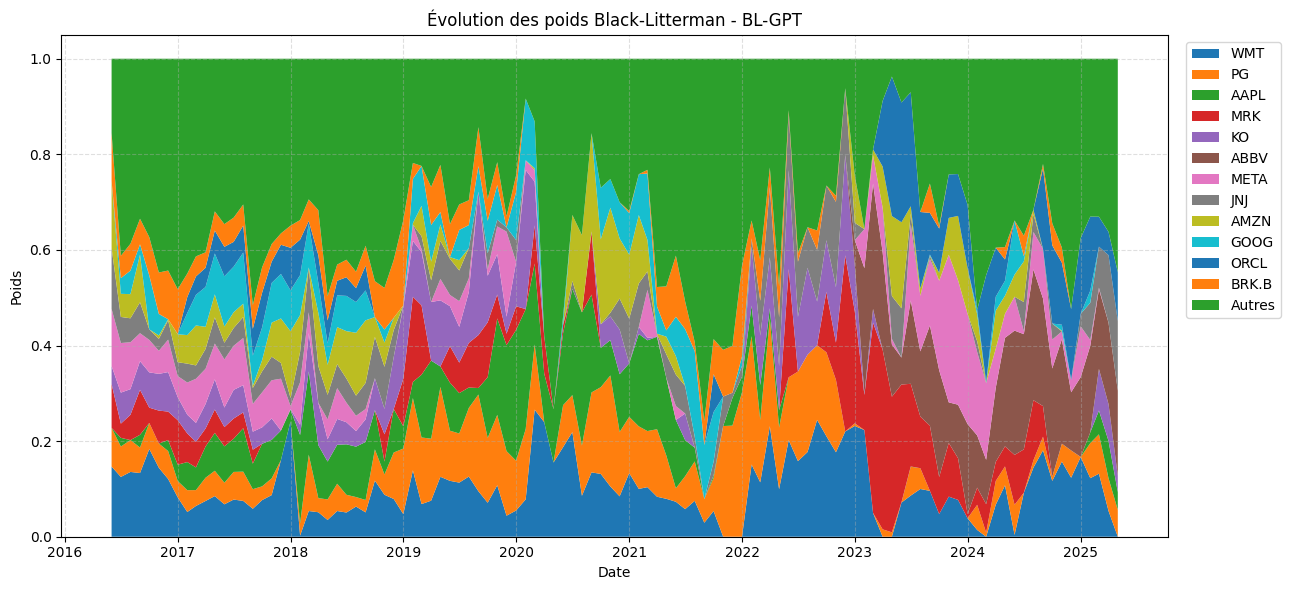

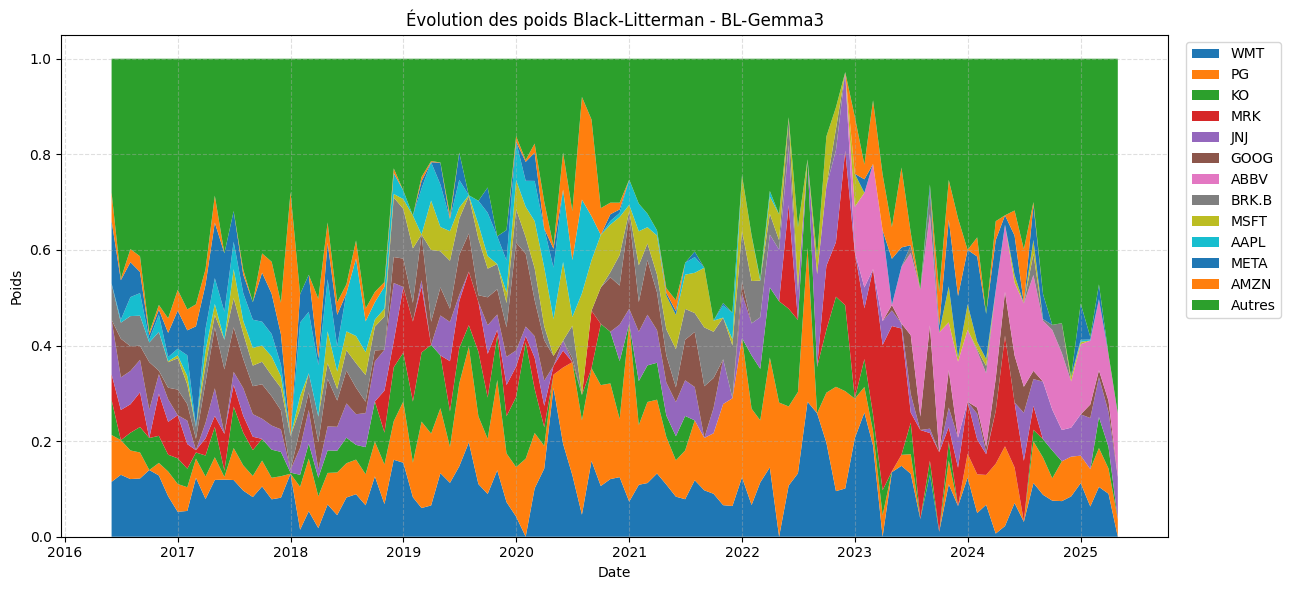

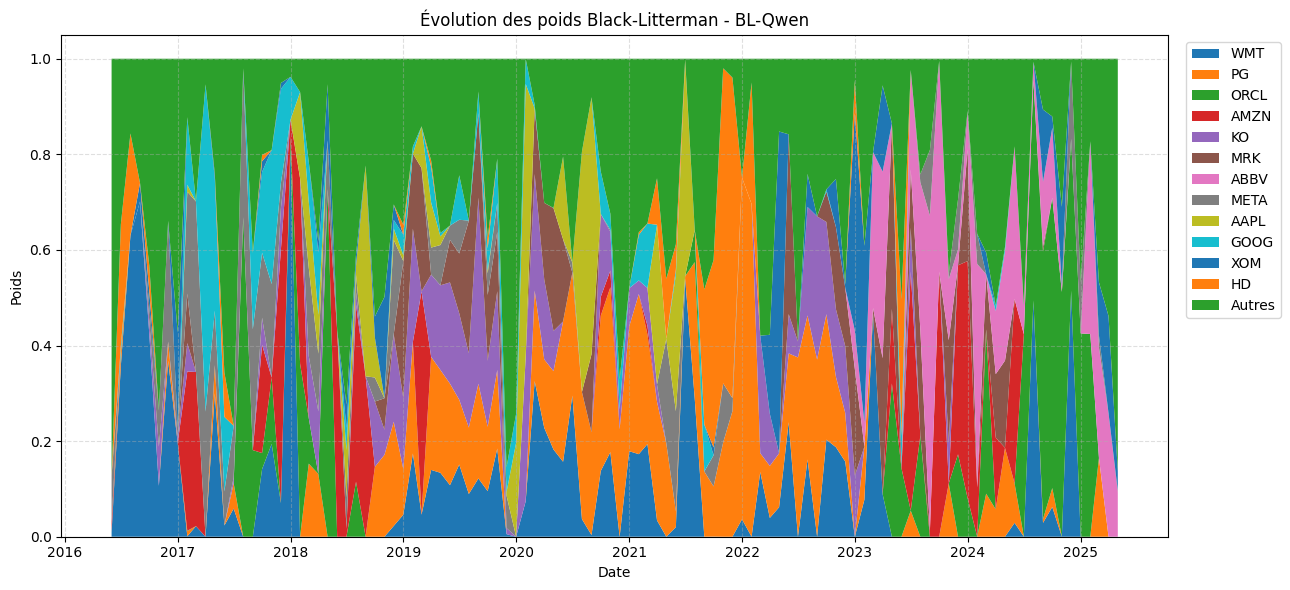

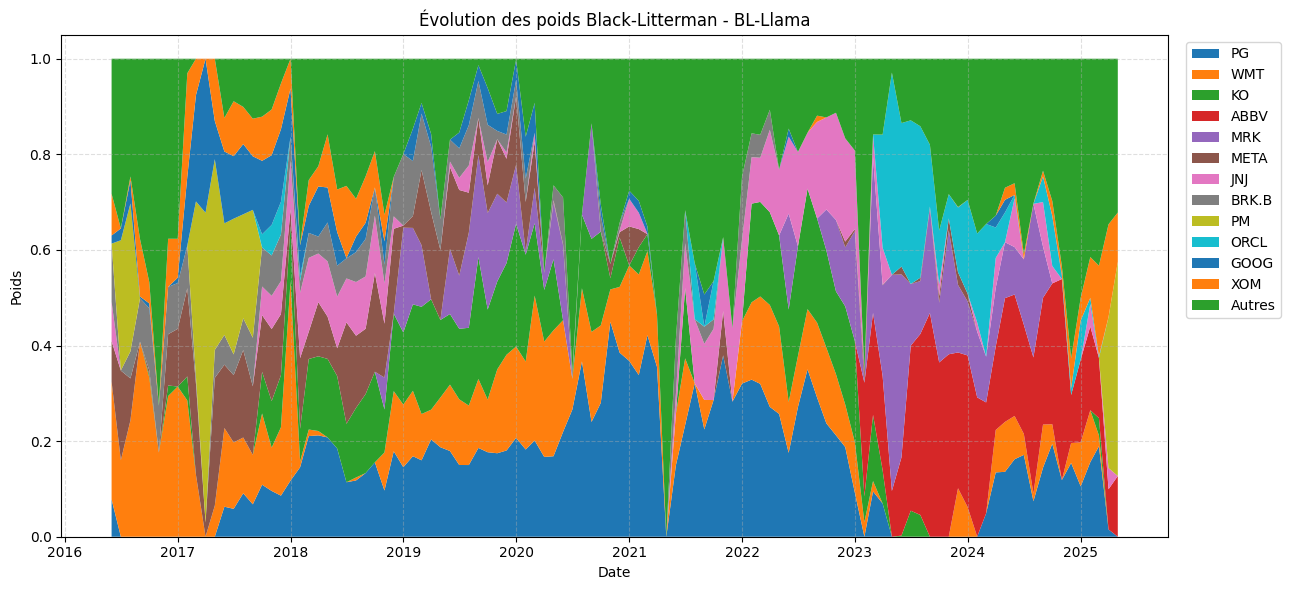

,model,avg_concentration_hhi,avg_effective_number_of_positions,avg_turnover,max_turnover,avg_gross_exposure,avg_net_exposure,avg_max_weight,avg_min_weight
0,BL-GPT,0.125091,9.572464,0.290821,0.608824,1.000000,1.000000,0.200011,0.000000
1,BL-Gemma3,0.114420,10.290376,0.340333,0.747387,1.000000,1.000000,0.181173,0.000000
2,BL-Llama,0.200374,5.691679,0.301588,1.000000,1.000000,1.000000,0.293994,0.000000
3,BL-Qwen,0.288945,4.157870,0.567596,1.000000,1.000000,1.000000,0.402930,0.000000


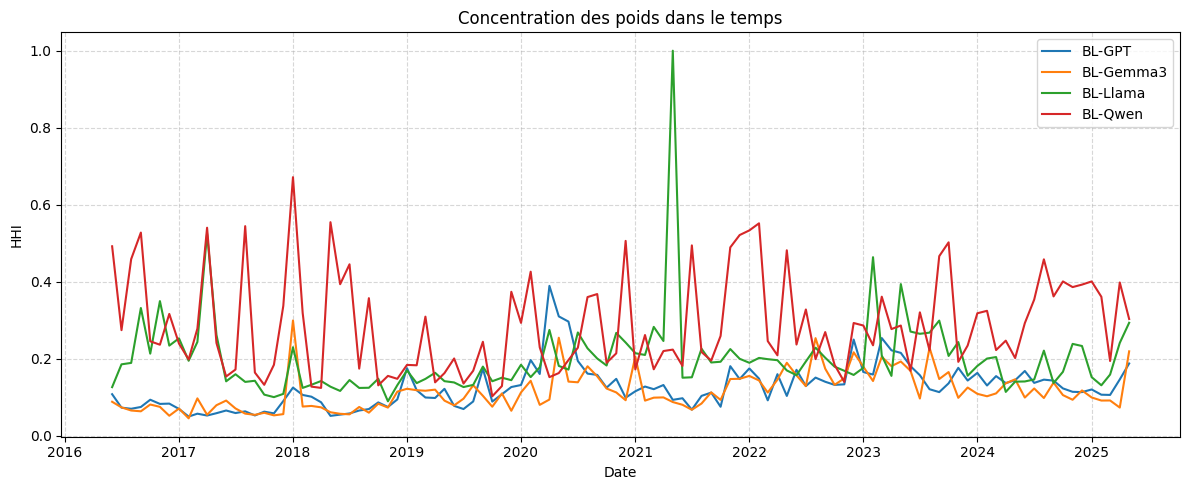

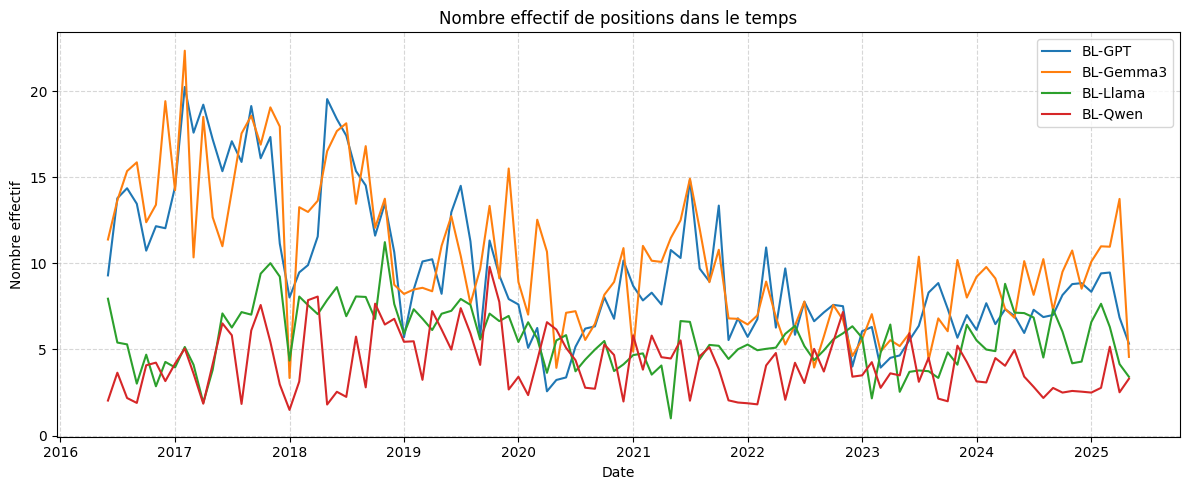

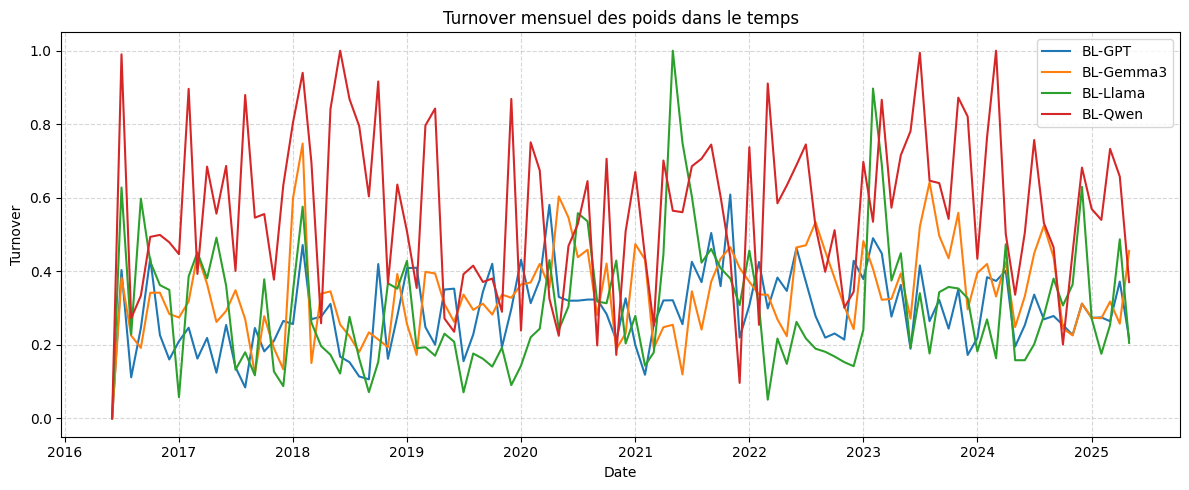

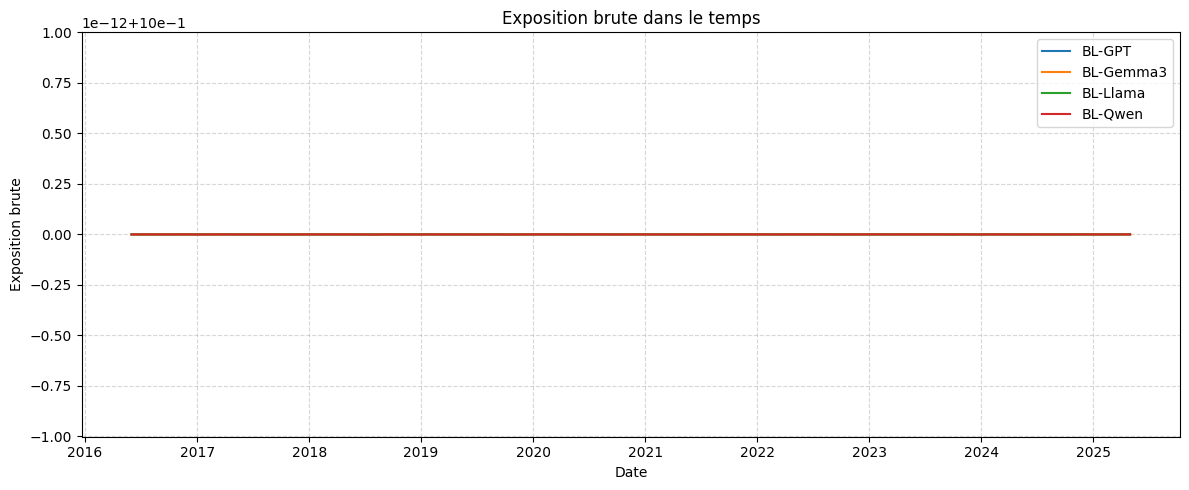

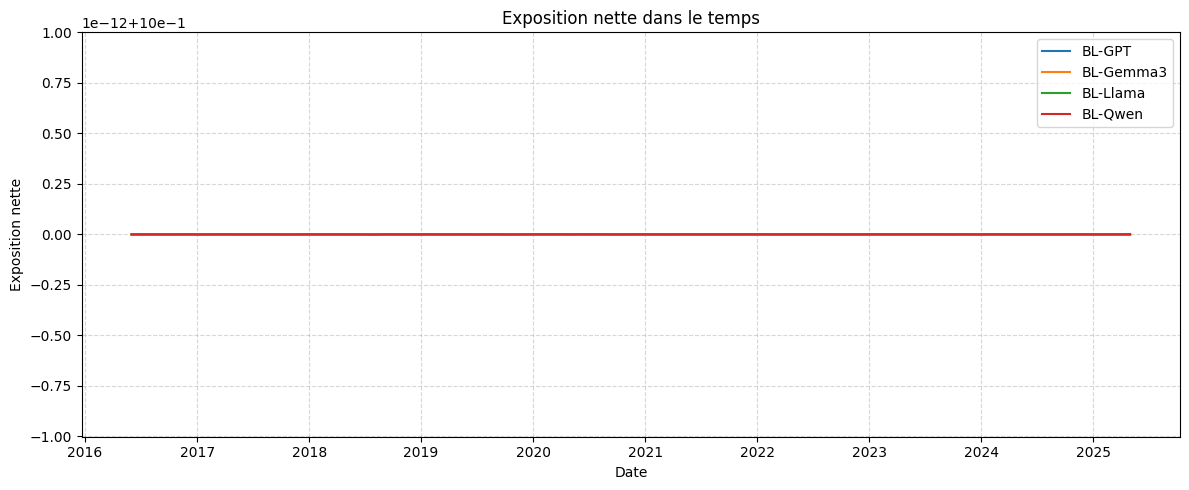

In [34]:

# ============================
# Graphiques de poids dans le temps
# ============================

OUTPUT_DIR = Path("style_analysis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

if "bl_weights" not in globals() or not bl_weights:
    raise ValueError(
        "Aucun poids Black-Litterman n'a été chargé. "
        "Vérifie la cellule de chargement des fichiers de poids dans results/."
    )


def clean_weights_df(weights: pd.DataFrame) -> pd.DataFrame:
    """
    Nettoie une matrice de poids:
    - index en datetime mensuel;
    - colonnes numériques;
    - valeurs manquantes remplacées par 0;
    - colonnes non numériques retirées.
    """
    w = weights.copy()

    # Si une colonne de date est présente plutôt que l'index.
    possible_date_cols = ["date_key", "Date", "date", "rebalance_date", "month", "ym"]
    date_col = next((c for c in possible_date_cols if c in w.columns), None)
    if date_col is not None:
        if date_col == "ym":
            dt = pd.to_datetime(w[date_col].astype(str).str[:7] + "-01", errors="coerce")
        else:
            dt = pd.to_datetime(w[date_col], errors="coerce")
        w = w.drop(columns=[date_col], errors="ignore")
        w.index = dt
    elif not isinstance(w.index, pd.DatetimeIndex):
        w.index = pd.to_datetime(w.index, errors="coerce")

    w = w.loc[~pd.isna(w.index)].copy()
    w.index = pd.DatetimeIndex(w.index).to_period("M").to_timestamp()
    w = w[~w.index.duplicated(keep="last")].sort_index()

    # Retirer colonnes qui ne sont clairement pas des poids.
    non_weight_cols = {
        "source_file", "Portfolio_Return", "portfolio_return", "return", "returns",
        "cum_return", "cumulative_return", "wealth", "model", "tau",
        "Unnamed: 0", "index"
    }
    w = w.drop(columns=[c for c in w.columns if c in non_weight_cols], errors="ignore")

    # Conversion numérique; colonnes entièrement vides retirées.
    for col in w.columns:
        w[col] = pd.to_numeric(w[col], errors="coerce")
    w = w.dropna(axis=1, how="all")

    return w.fillna(0)


def plot_stacked_weights(weights: pd.DataFrame, title: str, top_n: int = 12):
    w = clean_weights_df(weights)

    if w.empty or w.shape[1] == 0:
        print(f"Aucun poids disponible pour: {title}")
        return

    has_negative = (w < 0).any().any()

    # Afficher les top titres selon le poids moyen absolu; le reste est regroupé dans "Autres".
    top_cols = w.abs().mean().sort_values(ascending=False).head(top_n).index.tolist()
    plot_df = w[top_cols].copy()
    other_cols = [c for c in w.columns if c not in top_cols]
    if other_cols:
        plot_df["Autres"] = w[other_cols].sum(axis=1)

    if has_negative:
        print(f"{title}: certains poids sont négatifs. Graphique en lignes utilisé au lieu d'un stackplot.")
        plt.figure(figsize=(13, 6))
        for col in plot_df.columns:
            plt.plot(plot_df.index, plot_df[col], label=col)
        plt.axhline(0, linewidth=1)
    else:
        plt.figure(figsize=(13, 6))
        plt.stackplot(
            plot_df.index,
            [plot_df[c].values for c in plot_df.columns],
            labels=plot_df.columns
        )

    plt.title(title)
    plt.ylabel("Poids")
    plt.xlabel("Date")
    plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


def compute_weight_diagnostics(weights: pd.DataFrame) -> pd.DataFrame:
    w = clean_weights_df(weights)

    concentration = (w ** 2).sum(axis=1)
    turnover = w.diff().abs().sum(axis=1) / 2
    n_effective = 1 / concentration.replace(0, np.nan)

    gross_exposure = w.abs().sum(axis=1)
    net_exposure = w.sum(axis=1)
    max_weight = w.max(axis=1)
    min_weight = w.min(axis=1)

    return pd.DataFrame({
        "concentration_hhi": concentration,
        "effective_number_of_positions": n_effective,
        "turnover": turnover,
        "gross_exposure": gross_exposure,
        "net_exposure": net_exposure,
        "max_weight": max_weight,
        "min_weight": min_weight,
    }, index=w.index)


weight_diag = []

for name, w in bl_weights.items():
    try:
        w_clean = clean_weights_df(w)

        if w_clean.empty or w_clean.shape[1] == 0:
            print(f"{name}: aucun poids valide.")
            continue

        plot_stacked_weights(w_clean, f"Évolution des poids Black-Litterman - {name}")

        d = compute_weight_diagnostics(w_clean)
        d["model"] = name

        # reset_index() peut créer une colonne nommée index, date_key, rebalance_date, etc.
        # On force donc la première colonne à s'appeler date.
        d = d.reset_index()
        first_col = d.columns[0]
        d = d.rename(columns={first_col: "date"})

        weight_diag.append(d)

    except Exception as e:
        print(f"Erreur avec {name}: {e}")

if not weight_diag:
    raise ValueError("Aucun diagnostic de poids n'a pu être calculé.")

weight_diag = pd.concat(weight_diag, ignore_index=True)

# Sécurité additionnelle : s'assurer que la colonne date existe bien.
if "date" not in weight_diag.columns:
    possible_date_cols = [c for c in weight_diag.columns if "date" in str(c).lower() or "time" in str(c).lower()]

    if possible_date_cols:
        weight_diag = weight_diag.rename(columns={possible_date_cols[0]: "date"})
    else:
        raise KeyError(
            f"Aucune colonne de date trouvée dans weight_diag. Colonnes disponibles: {list(weight_diag.columns)}"
        )

weight_diag["date"] = pd.to_datetime(weight_diag["date"], errors="coerce")
weight_diag = weight_diag.dropna(subset=["date"])

weight_diag_summary = (
    weight_diag
    .groupby("model")
    .agg(
        avg_concentration_hhi=("concentration_hhi", "mean"),
        avg_effective_number_of_positions=("effective_number_of_positions", "mean"),
        avg_turnover=("turnover", "mean"),
        max_turnover=("turnover", "max"),
        avg_gross_exposure=("gross_exposure", "mean"),
        avg_net_exposure=("net_exposure", "mean"),
        avg_max_weight=("max_weight", "mean"),
        avg_min_weight=("min_weight", "mean"),
    )
    .reset_index()
)

display(weight_diag_summary)

weight_diag.to_csv(OUTPUT_DIR / "weight_diagnostics_monthly.csv", index=False)
weight_diag_summary.to_csv(OUTPUT_DIR / "weight_diagnostics_summary.csv", index=False)

for metric, ylabel, title in [
    ("concentration_hhi", "HHI", "Concentration des poids dans le temps"),
    ("effective_number_of_positions", "Nombre effectif", "Nombre effectif de positions dans le temps"),
    ("turnover", "Turnover", "Turnover mensuel des poids dans le temps"),
    ("gross_exposure", "Exposition brute", "Exposition brute dans le temps"),
    ("net_exposure", "Exposition nette", "Exposition nette dans le temps"),
]:
    if metric not in weight_diag.columns:
        print(f"Métrique absente: {metric}")
        continue

    pivot = weight_diag.pivot(index="date", columns="model", values=metric).sort_index()

    plt.figure(figsize=(12, 5))
    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col], label=col)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("Date")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


## 13. Construction des poids du S&P 500

Cette section reconstruit les poids mensuels du S&P 500 à partir de `filtered_sp500_data.csv`. Le fichier est supposé contenir uniquement les entreprises appartenant au S&P 500 à chaque date. Les poids sont donc calculés directement à partir de la capitalisation boursière disponible dans le fichier, sans refaire de filtre de constituants.

Chargement des données S&P 500 depuis: data\filtered_sp25_data.csv
Chevauchement des identifiants S&P 500 avec les colonnes BL:
  tic: 42 identifiants communs
  gvkey: 0 identifiants communs
Colonne date utilisée: date
Colonne identifiant utilisée: tic
Colonne market cap utilisée: market_equity
Poids S&P 500 construits: 109 mois, 41 titres.
Somme des poids par mois:


count   109.000000
mean      1.000000
std       0.000000
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       1.000000
dtype: float64

tic,AAPL,ABBV,ADBE,AMZN,AVGO,BA,BAC,BRK.B,CRM,CSCO,...,PM,PYPL,T,TSLA,UNH,V,VZ,WFC,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,,
2016-06-01,0.095629,0.000000,0.000000,0.059624,0.000000,0.000000,0.026561,0.030851,0.000000,0.000000,...,0.026763,0.000000,0.042139,0.000000,0.000000,0.000000,0.036275,0.045021,0.038841,0.064536
2016-07-01,0.089663,0.000000,0.000000,0.058989,0.000000,0.000000,0.000000,0.031616,0.000000,0.000000,...,0.027441,0.000000,0.046262,0.000000,0.000000,0.000000,0.039582,0.041789,0.039577,0.067598
2016-08-01,0.094508,0.000000,0.000000,0.060544,0.000000,0.000000,0.000000,0.030488,0.000000,0.000000,...,0.026177,0.000000,0.044823,0.000000,0.000000,0.000000,0.038015,0.040759,0.038276,0.062078
2016-09-01,0.093592,0.000000,0.000000,0.059693,0.000000,0.000000,0.026963,0.031594,0.000000,0.025881,...,0.025378,0.000000,0.041171,0.000000,0.000000,0.000000,0.034920,0.041960,0.036176,0.059153
2016-10-01,0.101876,0.000000,0.000000,0.066515,0.000000,0.000000,0.026709,0.030985,0.000000,0.026600,...,0.000000,0.000000,0.041782,0.000000,0.000000,0.000000,0.035436,0.037364,0.037309,0.060527


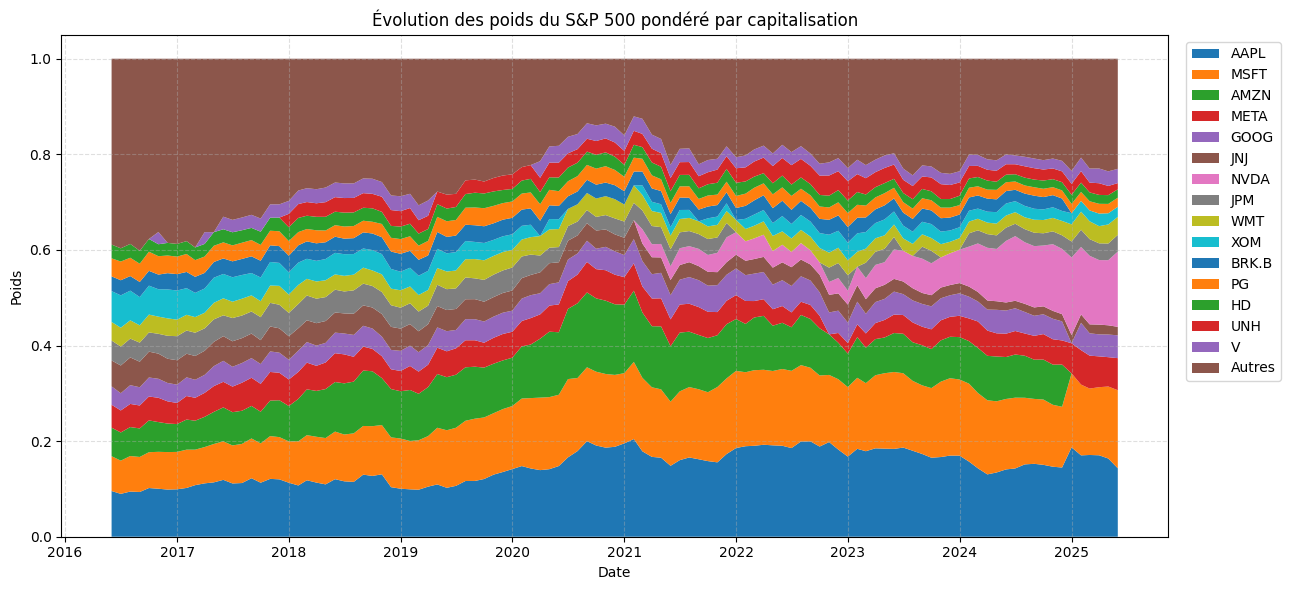

,date,concentration_hhi,effective_number_of_positions,turnover,gross_exposure,net_exposure,max_weight,min_weight,model
count,109,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109.000000,109
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S&P 500
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,109
mean,2020-11-30 12:33:01.651376128,0.073387,14.365104,0.041364,1.000000,1.000000,0.148403,0.000000,NaN
min,2016-06-01 00:00:00,0.046700,9.327033,0.000000,1.000000,1.000000,0.089663,0.000000,NaN
25%,2018-09-01 00:00:00,0.057279,11.808352,0.026353,1.000000,1.000000,0.118571,0.000000,NaN
50%,2020-12-01 00:00:00,0.077845,12.845973,0.037911,1.000000,1.000000,0.150774,0.000000,NaN
75%,2023-03-01 00:00:00,0.084686,17.458382,0.050193,1.000000,1.000000,0.178633,0.000000,NaN
max,2025-06-01 00:00:00,0.107215,21.413276,0.214004,1.000000,1.000000,0.204356,0.000000,NaN


In [35]:

# ============================
# Construction des poids du S&P 500
# ============================

SP500_DATA_PATH_CANDIDATES = [
    Path("data/filtered_sp25_data.csv"),
    Path("filtered_sp25_data.csv"),
    Path("../data/filtered_sp25_data.csv"),
]

# Colonnes possibles. Le code choisit automatiquement la première trouvée.
SP500_DATE_COL_CANDIDATES = ["date_key", "date", "Date", "month", "ym", "char_date"]
SP500_ID_COL_CANDIDATES = ["ticker", "tickers", "symbol", "tic", "gvkey", "permno", "iid"]
SP500_MCAP_COL_CANDIDATES = ["market_equity", "mktcap", "market_cap", "me", "mve", "size"]


def _find_sp500_data_path() -> Path:
    for path in SP500_DATA_PATH_CANDIDATES:
        if path.exists():
            return path
    raise FileNotFoundError(
        "Impossible de trouver filtered_sp500_data.csv. "
        "Chemins testés: "
        + ", ".join(str(p) for p in SP500_DATA_PATH_CANDIDATES)
    )


def _pick_col(df: pd.DataFrame, candidates: list[str], label: str) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(
        f"Aucune colonne {label} trouvée. "
        f"Colonnes disponibles: {list(df.columns)}"
    )


def _parse_month_from_col(s: pd.Series, col_name: str) -> pd.Series:
    """
    Convertit une colonne de date en mois.
    Gère notamment:
    - dates standard;
    - entiers YYYYMMDD;
    - strings YYYY-MM;
    - strings YYYYMM.
    """
    x = s.copy()

    # Cas fréquent: date au format YYYYMMDD numérique.
    if pd.api.types.is_numeric_dtype(x):
        x_str = x.astype("Int64").astype(str)
        if x_str.str.len().median() >= 8:
            dt = pd.to_datetime(x_str, format="%Y%m%d", errors="coerce")
        elif x_str.str.len().median() == 6:
            dt = pd.to_datetime(x_str + "01", format="%Y%m%d", errors="coerce")
        else:
            dt = pd.to_datetime(x, errors="coerce")
    else:
        x_str = x.astype(str).str.strip()

        # Cas YYYY-MM ou YYYY/MM.
        looks_ym = x_str.str.match(r"^\d{4}[-/]\d{1,2}$", na=False)
        if looks_ym.mean() > 0.8:
            dt = pd.to_datetime(x_str.str.replace("/", "-", regex=False) + "-01", errors="coerce")
        # Cas YYYYMM.
        elif x_str.str.match(r"^\d{6}$", na=False).mean() > 0.8:
            dt = pd.to_datetime(x_str + "01", format="%Y%m%d", errors="coerce")
        # Cas général.
        else:
            dt = pd.to_datetime(x, errors="coerce")

    return dt.dt.to_period("M").dt.to_timestamp()


def _choose_id_col_for_overlap(df: pd.DataFrame, bl_weights: dict[str, pd.DataFrame]) -> str:
    """
    Choisit une colonne d'identifiant. Si plusieurs colonnes existent, on privilégie celle
    qui maximise le chevauchement avec les colonnes des poids BL.
    """
    available = [c for c in SP500_ID_COL_CANDIDATES if c in df.columns]

    if not available:
        raise ValueError(
            "Aucune colonne d'identifiant trouvée pour construire les poids S&P 500. "
            f"Colonnes disponibles: {list(df.columns)}"
        )

    # Ensemble des identifiants utilisés par les poids BL.
    bl_cols = set()
    if isinstance(bl_weights, dict):
        for w in bl_weights.values():
            bl_cols.update(map(str, w.columns))

    if not bl_cols:
        return available[0]

    overlap_scores = {}
    for c in available:
        vals = set(df[c].dropna().astype(str).unique())
        overlap_scores[c] = len(vals.intersection(bl_cols))

    best_col = max(overlap_scores, key=overlap_scores.get)

    print("Chevauchement des identifiants S&P 500 avec les colonnes BL:")
    for c, score in overlap_scores.items():
        print(f"  {c}: {score} identifiants communs")

    if overlap_scores[best_col] == 0:
        print(
            "Attention: aucun chevauchement détecté entre les identifiants du S&P 500 "
            "et les colonnes des poids BL. L'active share vs S&P 500 risque d'être non informative. "
            "Vérifie si les poids BL utilisent des tickers alors que filtered_sp500_data.csv utilise des gvkey, ou inversement."
        )

    return best_col


def load_sp500_cap_weighted_weights(
    data_path: Path | None = None,
    date_col: str | None = None,
    id_col: str | None = None,
    mcap_col: str | None = None,
) -> pd.DataFrame:
    """
    Reconstruit les poids mensuels du S&P 500 à partir des capitalisations boursières.

    Hypothèse importante:
    - filtered_sp500_data.csv contient déjà seulement les entreprises du S&P 500 dans le temps.
      On ne refiltre donc pas les constituants.

    Retour:
    - DataFrame indexé par mois;
    - colonnes = tickers/gvkey/identifiants;
    - valeurs = poids cap-weighted.
    """
    if data_path is None:
        data_path = _find_sp500_data_path()
    else:
        data_path = Path(data_path)

    print(f"Chargement des données S&P 500 depuis: {data_path}")

    df = pd.read_csv(data_path)

    date_col = date_col or _pick_col(df, SP500_DATE_COL_CANDIDATES, "de date")
    id_col = id_col or _choose_id_col_for_overlap(df, bl_weights)
    mcap_col = mcap_col or _pick_col(df, SP500_MCAP_COL_CANDIDATES, "de capitalisation boursière")

    print(f"Colonne date utilisée: {date_col}")
    print(f"Colonne identifiant utilisée: {id_col}")
    print(f"Colonne market cap utilisée: {mcap_col}")

    df = df[[date_col, id_col, mcap_col]].copy()
    df["month"] = _parse_month_from_col(df[date_col], date_col)
    df[id_col] = df[id_col].astype(str).str.strip()
    df[mcap_col] = pd.to_numeric(df[mcap_col], errors="coerce")

    df = df.dropna(subset=["month", id_col, mcap_col])
    df = df[df[mcap_col] > 0]

    start_month = START_DT.to_period("M").to_timestamp()
    end_month = END_DT.to_period("M").to_timestamp()
    df = df[(df["month"] >= start_month) & (df["month"] <= end_month)]

    if df.empty:
        raise ValueError("Aucune observation S&P 500 valide dans la période START / END.")

    # Si plusieurs observations par identifiant dans un mois, garder la dernière observation du mois.
    # Comme filtered_sp500_data.csv contient déjà l'univers S&P 500, aucun filtre additionnel de constituants n'est appliqué.
    df = (
        df.sort_values(["month", id_col, date_col])
        .groupby(["month", id_col], as_index=False)
        .tail(1)
    )

    # Calcul des poids cap-weighted par mois.
    df["total_mcap"] = df.groupby("month")[mcap_col].transform("sum")
    df["weight"] = df[mcap_col] / df["total_mcap"]

    sp500_weights = (
        df.pivot(index="month", columns=id_col, values="weight")
        .fillna(0)
        .sort_index()
    )

    sp500_weights.index.name = "date"

    # Sécurité: normaliser les lignes au cas où il y aurait de très petits écarts numériques.
    row_sums = sp500_weights.sum(axis=1)
    sp500_weights = sp500_weights.div(row_sums.replace(0, np.nan), axis=0).fillna(0)

    return sp500_weights


sp500_weights = load_sp500_cap_weighted_weights()

print(
    f"Poids S&P 500 construits: "
    f"{sp500_weights.shape[0]} mois, {sp500_weights.shape[1]} titres."
)
print("Somme des poids par mois:")
display(sp500_weights.sum(axis=1).describe())

display(sp500_weights.head())

# Export des poids S&P 500.
OUTPUT_DIR.mkdir(exist_ok=True)
sp500_weights.to_csv(OUTPUT_DIR / "sp500_cap_weighted_weights.csv")

# Graphique des poids du S&P 500.
plot_stacked_weights(
    sp500_weights,
    "Évolution des poids du S&P 500 pondéré par capitalisation",
    top_n=15
)

# Diagnostics des poids S&P 500.
sp500_diag = compute_weight_diagnostics(sp500_weights)
sp500_diag["model"] = "S&P 500"
sp500_diag_out = sp500_diag.reset_index().rename(columns={sp500_diag.reset_index().columns[0]: "date"})

display(sp500_diag_out.describe(include="all"))

sp500_diag_out.to_csv(OUTPUT_DIR / "sp500_weight_diagnostics_monthly.csv", index=False)


## 14. Comparaison des poids LLM-BLM avec EW, MVO et S&P 500

Cette section compare les poids Black-Litterman issus des LLMs avec trois références : un portefeuille équipondéré reconstruit sur le même univers, les poids MVO lorsqu’ils sont disponibles, et le S&P 500 pondéré par capitalisation reconstruit à partir de `filtered_sp500_data.csv`.

Aucun fichier MVO trouvé au chemin exact: results\mvo_weights.csv


,model,benchmark,n_months,avg_active_share,max_active_share,avg_l1_distance
0,BL-GPT,EW,108,0.693140,0.902439,1.386280
1,BL-GPT,S&P 500,108,0.544885,0.827335,1.089771
2,BL-Gemma3,EW,108,0.680738,0.878383,1.361476
3,BL-Gemma3,S&P 500,108,0.563242,0.870513,1.126485
4,BL-Qwen,EW,108,0.844627,0.946858,1.689255
5,BL-Qwen,S&P 500,108,0.770971,0.942127,1.541943
6,BL-Llama,EW,108,0.807922,0.975610,1.615843
7,BL-Llama,S&P 500,108,0.744336,0.982849,1.488671


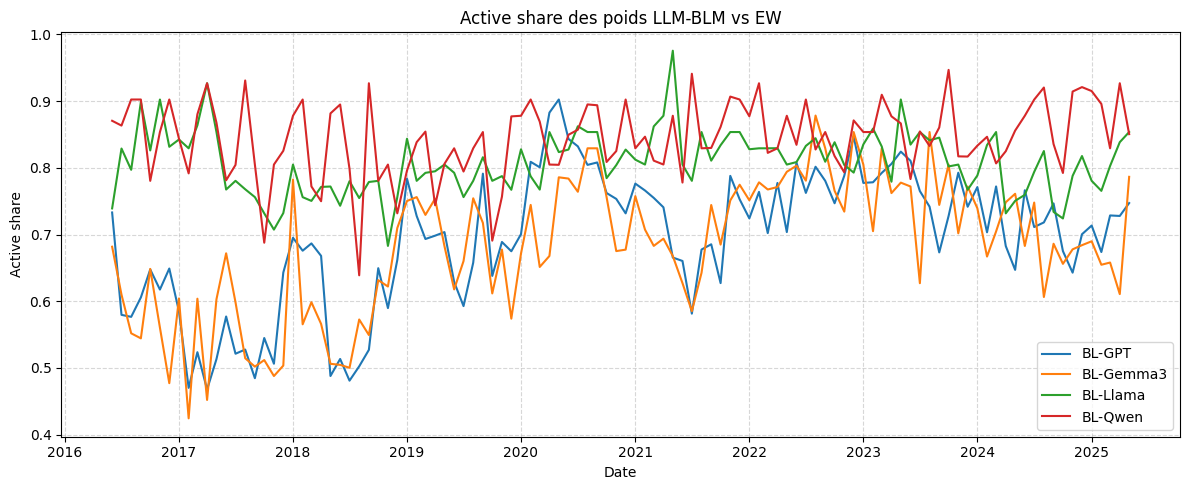

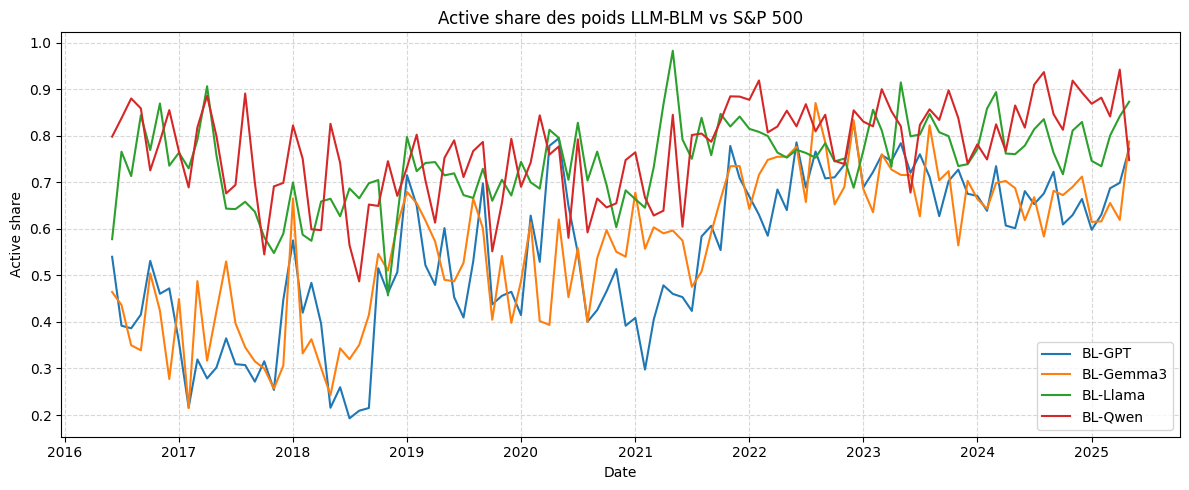

In [36]:
# ============================
# Comparaison des poids : LLM vs EW / MVO / S&P 500
# ============================

MVO_WEIGHTS_PATH = RESULTS_DIR / "mvo_weights.csv"


def make_equal_weight_from_universe(weights: pd.DataFrame) -> pd.DataFrame:
    """
    Reconstruit un portefeuille équipondéré à partir du même univers que les poids BL.
    Chaque mois, tous les titres présents dans les colonnes reçoivent un poids 1/N.
    """
    weights = clean_weights_df(weights)
    cols = list(weights.columns)

    if len(cols) == 0:
        raise ValueError("Impossible de construire EW: aucune colonne de poids dans weights.")

    ew = pd.DataFrame(
        1 / len(cols),
        index=weights.index,
        columns=cols
    )

    return ew


def load_mvo_weights_exact(path=MVO_WEIGHTS_PATH) -> pd.DataFrame | None:
    """
    Charge seulement results/mvo_weights.csv.
    Ne teste pas plusieurs conventions de noms.
    """
    path = Path(path)

    if not path.exists():
        print(f"Aucun fichier MVO trouvé au chemin exact: {path}")
        return None

    try:
        w = _clean_weight_df(pd.read_csv(path), "MVO")
        w = clean_weights_df(w)
    except Exception as e:
        print(f"Fichier MVO trouvé mais non lisible comme poids: {path} | {e}")
        return None

    if w.shape[1] <= 1:
        print(f"Le fichier MVO ne semble pas contenir des poids détaillés: {path}")
        return None

    suspect_return_cols = [
        c for c in w.columns
        if "return" in str(c).lower() or "rend" in str(c).lower()
    ]
    w = w.drop(columns=suspect_return_cols, errors="ignore")

    print(f"Poids MVO chargés depuis: {path}")
    return w


def align_weight_pair(w1: pd.DataFrame, w2: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    w1 = clean_weights_df(w1)
    w2 = clean_weights_df(w2)

    idx = w1.index.intersection(w2.index)
    cols = sorted(set(map(str, w1.columns)).union(set(map(str, w2.columns))))

    # Forcer les noms de colonnes en str pour éviter les non-alignements int vs str.
    a = w1.copy()
    b = w2.copy()
    a.columns = a.columns.astype(str)
    b.columns = b.columns.astype(str)

    a = a.reindex(index=idx, columns=cols).fillna(0).sort_index()
    b = b.reindex(index=idx, columns=cols).fillna(0).sort_index()

    return a, b


def active_share(w1: pd.DataFrame, w2: pd.DataFrame) -> pd.Series:
    a, b = align_weight_pair(w1, w2)
    if a.empty:
        return pd.Series(dtype=float)
    return 0.5 * (a - b).abs().sum(axis=1)


def l1_distance(w1: pd.DataFrame, w2: pd.DataFrame) -> pd.Series:
    a, b = align_weight_pair(w1, w2)
    if a.empty:
        return pd.Series(dtype=float)
    return (a - b).abs().sum(axis=1)


def _append_weight_comparison(
    comparison_rows: list,
    comparison_ts: list,
    model_name: str,
    benchmark_name: str,
    w_model: pd.DataFrame,
    w_benchmark: pd.DataFrame,
):
    as_series = active_share(w_model, w_benchmark)
    l1_series = l1_distance(w_model, w_benchmark)

    if as_series.empty:
        print(f"Comparaison ignorée: {model_name} vs {benchmark_name} | aucune date commune.")
        return

    comparison_ts.append(pd.DataFrame({
        "date": as_series.index,
        "model": model_name,
        "benchmark": benchmark_name,
        "active_share": as_series.values,
        "l1_distance": l1_series.reindex(as_series.index).values,
    }))

    comparison_rows.append({
        "model": model_name,
        "benchmark": benchmark_name,
        "n_months": len(as_series),
        "avg_active_share": as_series.mean(),
        "max_active_share": as_series.max(),
        "avg_l1_distance": l1_series.mean(),
    })


mvo_weights = load_mvo_weights_exact()

# sp500_weights est construit dans la cellule précédente.
if "sp500_weights" not in globals():
    print("sp500_weights n'existe pas encore. Exécute la cellule de construction des poids S&P 500.")
    sp500_weights = None

comparison_rows = []
comparison_ts = []

for name, w in bl_weights.items():
    # EW est reconstruit à partir du même univers que BL.
    ew = make_equal_weight_from_universe(w)
    _append_weight_comparison(comparison_rows, comparison_ts, name, "EW", w, ew)

    # Comparaison avec MVO.
    if mvo_weights is not None:
        _append_weight_comparison(comparison_rows, comparison_ts, name, "MVO", w, mvo_weights)

    # Comparaison avec S&P 500 cap-weighted.
    if sp500_weights is not None:
        _append_weight_comparison(comparison_rows, comparison_ts, name, "S&P 500", w, sp500_weights)


if not comparison_rows:
    raise ValueError("Aucune comparaison de poids n'a pu être calculée.")

weight_comparison_summary = pd.DataFrame(comparison_rows)
weight_comparison_ts = pd.concat(comparison_ts, ignore_index=True)

display(weight_comparison_summary)

OUTPUT_DIR.mkdir(exist_ok=True)
weight_comparison_summary.to_csv(OUTPUT_DIR / "weight_comparison_summary.csv", index=False)
weight_comparison_ts.to_csv(OUTPUT_DIR / "weight_comparison_timeseries.csv", index=False)


for bench in sorted(weight_comparison_ts["benchmark"].unique()):
    pivot = (
        weight_comparison_ts[weight_comparison_ts["benchmark"] == bench]
        .pivot(index="date", columns="model", values="active_share")
        .sort_index()
    )

    plt.figure(figsize=(12, 5))
    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col], label=col)

    plt.title(f"Active share des poids LLM-BLM vs {bench}")
    plt.ylabel("Active share")
    plt.xlabel("Date")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()
